# Recopilación y preparación de datos
## Modelo de riesgo de default crediticio — Lending Club
**Ciencia de Datos Aplicada · ITBA · Segundo entregable**

Gianluca Giannine Lizarraga · Timoteo Harrington · Lucas Kim

Este notebook retoma la propuesta del Entregable 01: estimar la probabilidad de default (PD) de un solicitante a partir de información disponible al momento de la solicitud, traducirla en bandas de riesgo y estimar una prima de riesgo de default (PD × LGD). Acá se adquiere el dataset, se diagnostica su calidad y se dejan los datos preparados para el modelado (Entrega 03).

**Contenido**
1. Descripción del dataset
2. Población de modelado: variable objetivo y maduración de las cosechas
3. Clasificación de variables: ex-ante vs. ex-post (data leakage)
4. Split temporal train/test
5. Diagnóstico de calidad de los datos (sobre train)
6. Análisis exploratorio sobre train
7. Cálculo empírico del LGD
8. Transformaciones y dataset final
9. Reflexión final

**Vocabulario: cosecha.** A lo largo del notebook se habla de **cosechas** (en inglés, *vintages*), un término estándar en riesgo crediticio: una cosecha es el conjunto de préstamos originados en un mismo período. Por ejemplo, la "cosecha 2013" son todos los préstamos otorgados durante 2013. Agrupar por cosecha permite comparar préstamos que tuvieron el mismo tiempo para terminar de pagarse y que se otorgaron en el mismo contexto económico.

El código reutilizable está en `src/`: carga de datos (`datos.py`), clasificación de variables y transformaciones (`features.py`) y estilo de gráficos (`graficos.py`). Así la Entrega 03 aplica exactamente las mismas transformaciones sin copiar código.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.metrics import roc_auc_score

from src import datos
from src import features as F
from src.graficos import aplicar_estilo, guardar, AZUL, NARANJA, GRIS, CMAP_SECUENCIAL

aplicar_estilo()
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)
pct = mtick.PercentFormatter(1.0, decimals=0)

## 1. Descripción del dataset

**Origen.** Lending Club fue la mayor plataforma de préstamos personales *peer-to-peer* de Estados Unidos. Durante años publicó en su sitio, para inversores, el detalle de todos los préstamos que otorgaba: datos del solicitante al momento de pedirlo y la evolución posterior del préstamo. Esos archivos ya no están disponibles en el sitio de Lending Club. Usamos la compilación publicada en Kaggle, que es la fuente citada en el Entregable 01:

- Dataset: [*Lending Club Loan Data* (wordsforthewise/lending-club)](https://www.kaggle.com/datasets/wordsforthewise/lending-club)
- Archivo: `accepted_2007_to_2018Q4.csv.gz` — préstamos otorgados entre 2007 y 2018.
- El mismo dataset trae `rejected_2007_to_2018Q4.csv.gz` (solicitudes rechazadas). No se usa: no tiene resultado de pago (nunca se otorgaron) y solo trae unas pocas variables.

**Formato.** Un CSV comprimido (~393 MB; ~1,7 GB descomprimido), una fila por préstamo, 151 columnas sin codificar (texto y números tal como los publicaba Lending Club).

**Justificación de la elección.**
- Permite plantear el problema como clasificación binaria con un resultado observado: préstamos pagados vs. incumplidos.
- Separa claramente la información disponible al solicitar (ex-ante) de la que se genera después (ex-post), condición necesaria para un modelo de otorgamiento sin *data leakage*.
- Incluye el puntaje FICO y un historial de buró de crédito detallado, que son las variables con las que trabaja la industria.
- Trae los montos recuperados tras el default, lo que permite calcular el LGD empíricamente en vez de suponerlo.
- Incluye la calificación de riesgo propia de Lending Club (`grade`), que sirve como benchmark de industria (KPI del Entregable 01).
- Cubre un ciclo económico completo, incluyendo cosechas de la crisis de 2008.

**Reproducibilidad.** `python scripts/download_data.py` descarga el archivo (requiere un token de la API de Kaggle; ver README).

In [2]:
# Lectura liviana de todos los préstamos (5 columnas) para describir el dataset completo
resumen = datos.cargar_resumen()

print(f"Préstamos: {len(resumen):,}")
print(f"Columnas del archivo original: {len(pd.read_csv(datos.RUTA_RAW, nrows=0).columns)}")
print(f"Originación: {resumen['issue_d'].min():%b-%Y} a {resumen['issue_d'].max():%b-%Y}")
print(f"Último pago registrado (fecha de corte del dataset): {resumen['last_pymnt_d'].max():%b-%Y}")

Préstamos: 2,260,701
Columnas del archivo original: 151
Originación: Jun-2007 a Dec-2018
Último pago registrado (fecha de corte del dataset): Mar-2019


In [3]:
estados = resumen['loan_status'].value_counts(dropna=False).to_frame('prestamos')
estados['%'] = (estados['prestamos'] / len(resumen) * 100).round(2)
estados

,prestamos,%
loan_status,,
Fully Paid,1076751,47.63
Current,878317,38.85
Charged Off,268559,11.88
Late (31-120 days),21467,0.95
In Grace Period,8436,0.37
Late (16-30 days),4349,0.19
Does not meet the credit policy. Status:Fully Paid,1988,0.09
Does not meet the credit policy. Status:Charged Off,761,0.03
Default,40,0.00


`loan_status` es el estado de cada préstamo a la fecha de corte:

| Estado | Significado |
|---|---|
| Fully Paid | Pagado en su totalidad |
| Charged Off | Dado de baja como pérdida: el prestatario dejó de pagar y Lending Club no espera cobrar más en forma regular |
| Current | Al día, todavía en curso |
| In Grace Period / Late (16-30) / Late (31-120) | Con atraso, todavía sin resolver |
| Default | Más de 120 días de atraso, todavía no dado de baja |
| Does not meet the credit policy. Status: … | Préstamos de 2007-2010 que no cumplen la política de crédito vigente de Lending Club (se otorgaron con criterios que después se abandonaron) |

Las 33 filas sin estado son líneas de resumen al final de los archivos trimestrales originales, no préstamos.

### 1.1 Diccionario de las variables principales

El dataset tiene 151 columnas; en la Sección 3 se clasifican todas. Esta tabla describe las que se usan en el análisis.

| Variable | Significado | Tipo |
|---|---|---|
| `loan_amnt` | Monto solicitado (USD) | Numérica |
| `term` | Plazo: 36 o 60 meses | Categórica |
| `purpose` | Propósito declarado (consolidar deudas, tarjeta de crédito, etc.) | Categórica |
| `emp_title` / `emp_length` | Puesto declarado / antigüedad laboral (< 1 a 10+ años) | Texto / ordinal |
| `home_ownership` | Situación de vivienda: alquila, hipotecada, propia | Categórica |
| `annual_inc` | Ingreso anual declarado (USD) | Numérica |
| `verification_status` | Si Lending Club verificó el ingreso o su fuente | Categórica |
| `addr_state` | Estado de residencia | Categórica |
| `dti` | Pagos mensuales de deuda / ingreso mensual, sin hipoteca ni el préstamo pedido (%) | Numérica |
| `fico_range_low` / `fico_range_high` | Rango del puntaje FICO al solicitar (300-850; mayor = menor riesgo) | Numérica |
| `earliest_cr_line` | Mes de apertura de la primera línea de crédito | Fecha |
| `delinq_2yrs` | Moras de 30+ días en los últimos 2 años | Conteo |
| `inq_last_6mths` | Consultas de crédito en los últimos 6 meses | Conteo |
| `mths_since_last_delinq` / `mths_since_last_record` | Meses desde la última mora / último registro público negativo | Numérica |
| `open_acc` / `total_acc` | Líneas de crédito abiertas / totales | Conteo |
| `pub_rec` / `pub_rec_bankruptcies` / `tax_liens` | Registros públicos negativos / quiebras / embargos fiscales | Conteo |
| `revol_bal` / `revol_util` | Saldo de crédito revolvente (USD) / utilización del límite revolvente (%) | Numérica |
| `mort_acc`, `bc_util`, `tot_hi_cred_lim`, `acc_open_past_24mths`, … | Buró extendido (desde 2012): hipotecas, utilización de tarjetas, límite total, cuentas abiertas recientes, etc. | Numérica |
| `grade` / `sub_grade` | Calificación de riesgo interna de Lending Club (A-G / A1-G5) | Ordinal (benchmark) |
| `int_rate` / `installment` | Tasa asignada por Lending Club (%) / cuota mensual (USD) | Numérica (benchmark) |
| `issue_d` | Mes de originación | Fecha |
| `loan_status` | Estado al corte (origen de la variable objetivo) | Categórica |
| `total_rec_prncp` | Capital cobrado (USD) | Ex-post |
| `recoveries` / `collection_recovery_fee` | Recuperos posteriores al charge-off / costo de cobranza (USD) | Ex-post |
| `last_fico_range_*`, `last_pymnt_d`, `debt_settlement_flag`, `hardship_*` | FICO actualizado, último pago, acuerdos de pago y de refinanciación | Ex-post |

## 2. Población de modelado: variable objetivo y maduración de las cosechas

### 2.1 Variable objetivo

Seguimos lo definido en el Entregable 01:

- **default = 1**: préstamo `Charged Off`.
- **default = 0**: préstamo `Fully Paid`.

Se excluyen los préstamos no resueltos (`Current`, con atraso o en `Default` todavía no dado de baja), porque todavía no sabemos cómo terminan.

### 2.2 Maduración de las cosechas

Una cosecha está **madura** cuando prácticamente todos sus préstamos ya terminaron (se pagaron o entraron en default), así que su resultado final se conoce.

Excluir los préstamos en curso tiene una consecuencia que hay que resolver antes de cualquier análisis. El dataset tiene fecha de corte a fines de 2018; en las cosechas recientes, la mayoría de los préstamos todavía no terminó. Si se quedan solo los ya resueltos de esas cosechas, se seleccionan los que terminaron *antes de tiempo*: los que cayeron en default temprano o los que se precancelaron. La tasa de default observada en esas cosechas no es comparable con la de cosechas completas (**sesgo de censura**).

La tabla y el gráfico muestran, por plazo y año de originación, qué porcentaje de los préstamos ya está resuelto y cuál es la tasa de default entre los resueltos.

Este análisis define **qué préstamos entran** al estudio; todavía no hay split. Para no mirar el resultado de los préstamos del período que después va a ser test, la tasa de default de la cosecha 2015 a 36 meses no se muestra (esa cosecha incluye el test). La decisión se toma con el % de préstamos resueltos, que no depende del resultado de cada préstamo; la tasa de default de las demás cosechas solo ilustra el sesgo.

In [4]:
resumen['estado'] = resumen['loan_status'].str.replace(
    'Does not meet the credit policy. Status:', '', regex=False)
resumen['resuelto'] = resumen['estado'].isin(['Fully Paid', 'Charged Off'])
resumen['charged_off'] = resumen['estado'] == 'Charged Off'
resumen['anio'] = resumen['issue_d'].dt.year

maduracion = (
    resumen.dropna(subset=['plazo_meses'])
    .groupby(['plazo_meses', 'anio'])
    .agg(prestamos=('id', 'size'), pct_resuelto=('resuelto', 'mean'),
         defaults=('charged_off', 'sum'), resueltos=('resuelto', 'sum'))
)
maduracion['tasa_default_resueltos'] = maduracion['defaults'] / maduracion['resueltos']
maduracion = maduracion.drop(columns=['defaults', 'resueltos'])
# La cosecha 2015 a 36 meses incluye el período de test: su tasa de default no se mira
maduracion.loc[(36.0, 2015.0), 'tasa_default_resueltos'] = np.nan
maduracion.round(3)

prestamos  pct_resuelto  tasa_default_resueltos
plazo_meses anio                                                   
36.0        2007.0        603         1.000                   0.262
            2008.0       2393         1.000                   0.207
            2009.0       5281         1.000                   0.137
            2010.0       9156         1.000                   0.109
            2011.0      14101         1.000                   0.106
            2012.0      43470         1.000                   0.136
            2013.0     100422         1.000                   0.123
            2014.0     162570         1.000                   0.137
            2015.0     283173         0.999                     NaN
            2016.0     323495         0.718                   0.198
            2017.0     320419         0.401                   0.200
            2018.0     344671         0.120                   0.132
60.0        2010.0       3381         1.000                   0.224
            2011.0       7620         1.000                   0.236
            2012.0       9897         1.000                   0.277
            2013.0      34392         1.000                   0.251
            2014.0      73059         0.829                   0.311
            2015.0     137922         0.671                   0.364
            2016.0     110912         0.548                   0.364
            2017.0     123160         0.331                   0.329
            2018.0     150571         0.100                   0.226

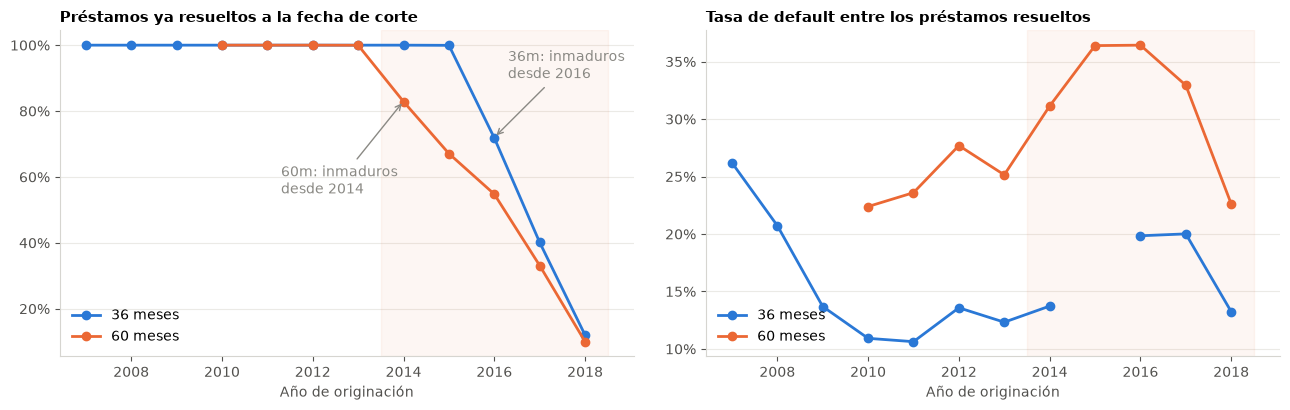

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for plazo, color in [(36, AZUL), (60, NARANJA)]:
    m = maduracion.loc[plazo]
    axes[0].plot(m.index, m['pct_resuelto'], marker='o', color=color, label=f'{plazo} meses')
    axes[1].plot(m.index, m['tasa_default_resueltos'], marker='o', color=color, label=f'{plazo} meses')

for ax in axes:
    ax.axvspan(2013.5, 2018.5, color=NARANJA, alpha=0.06)
    ax.yaxis.set_major_formatter(pct)
    ax.set_xlabel('Año de originación')
    ax.legend(loc='lower left')
axes[0].set_title('Préstamos ya resueltos a la fecha de corte')
axes[1].set_title('Tasa de default entre los préstamos resueltos')
axes[0].annotate('60m: inmaduros\ndesde 2014', xy=(2014, 0.83), xytext=(2011.3, 0.55),
                 color=GRIS, arrowprops=dict(arrowstyle='->', color=GRIS))
axes[0].annotate('36m: inmaduros\ndesde 2016', xy=(2016, 0.72), xytext=(2016.3, 0.9),
                 color=GRIS, arrowprops=dict(arrowstyle='->', color=GRIS))
plt.tight_layout()
guardar(fig, '01_maduracion_cosechas')
plt.show()

**Lectura.** (Esta tabla incluye todavía los préstamos fuera de la política de crédito de 2007-2010, que se excluyen más abajo; por eso la tasa de 2007-2008 es mayor que la de la Sección 6.)
- Los préstamos a **36 meses** están prácticamente 100% resueltos hasta la cosecha 2015; desde 2016 el porcentaje cae (72% en 2016, 12% en 2018).
- Los préstamos a **60 meses** están 100% resueltos solo hasta la cosecha 2013.
- En las cosechas inmaduras la tasa de default entre los resueltos se distorsiona: en 36 meses salta de ~14% (2014) a ~20% (2016-2017) sin que haya un cambio real en la calidad de los préstamos, solo porque los que terminaron primero son desproporcionadamente los que cayeron en default.

**Decisiones.**
1. **Se usan solo cosechas maduras**: la variable objetivo queda observada para (prácticamente) todos los préstamos de cada cosecha. Es la consecuencia directa de excluir los préstamos en curso, tal como se planteó en el Entregable 01.
2. **Se modelan solo los préstamos a 36 meses** (2007-2015). Motivos:
   - La PD de un préstamo a 60 meses cubre un horizonte de 5 años y la de uno a 36 meses, de 3 años: no son la misma probabilidad y mezclarlas vuelve ambiguo el output del modelo y la prima PD × LGD.
   - Los préstamos a 60 meses maduros terminan en 2013, así que un test temporal (las cosechas más recientes) no tendría ningún préstamo a 60 meses para evaluar.
   - Los 36 meses son el 92% de los préstamos de cosechas maduras.

   El modelo queda acotado al producto de 36 meses; esta limitación se documenta en la Sección 9.

In [6]:
# Lectura completa de las cosechas maduras (151 columnas).
# La primera ejecución lee el CSV por bloques y guarda un parquet (~2 min).
df = datos.cargar_cosechas_maduras()

embudo = [('Dataset completo (2007-2018)', len(resumen)),
          ('Cosechas maduras (36m hasta 2015, 60m hasta 2013)', len(df))]

df = df[df['term'].str.strip() == '36 months']
embudo.append(('Solo plazo 36 meses', len(df)))

df = df[~df['loan_status'].str.startswith('Does not meet')]
embudo.append(('Sin préstamos fuera de la política de crédito', len(df)))

df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])]
embudo.append(('Solo préstamos resueltos (Fully Paid / Charged Off)', len(df)))

df = df[df['application_type'] == 'Individual'].reset_index(drop=True)
embudo.append(('Solo solicitudes individuales', len(df)))

df['default'] = (df['loan_status'] == 'Charged Off').astype(int)
df['fecha_originacion'] = pd.to_datetime(df['issue_d'], format='%b-%Y')

embudo = pd.DataFrame(embudo, columns=['paso', 'prestamos']).set_index('paso')
embudo['excluidos'] = (-embudo['prestamos'].diff()).fillna(0).astype(int)
embudo

,prestamos,excluidos
paso,,
Dataset completo (2007-2018),2260701,0
"Cosechas maduras (36m hasta 2015, 60m hasta 2013)",676459,1584242
Solo plazo 36 meses,621169,55290
Sin préstamos fuera de la política de crédito,618731,2438
Solo préstamos resueltos (Fully Paid / Charged Off),618584,147
Solo solicitudes individuales,618345,239


- **Fuera de la política de crédito**: son préstamos de 2007-2010 otorgados con criterios que Lending Club abandonó. No representan a la población que el modelo va a evaluar.
- **No resueltos**: dentro de las cosechas maduras quedan unos pocos préstamos todavía abiertos (reestructurados o con atraso); se excluyen por la misma razón que los `Current`.
- **Solicitudes conjuntas**: Lending Club las habilitó recién a fines de 2015 y en la población hay solo 239. Sus variables (ingreso y DTI conjuntos, datos del co-solicitante) no existen para el resto, así que se excluyen.

## 3. Clasificación de variables: ex-ante vs. ex-post (data leakage)

Es el paso metodológico más importante del entregable. Cada una de las 151 columnas se clasifica según **si estaría disponible al momento de decidir el otorgamiento**. La clasificación vive en `src/features.py` para que la Entrega 03 use exactamente las mismas listas.

| Categoría | Criterio | Uso |
|---|---|---|
| **Ex-ante** | Datos del solicitante y de su buró de crédito al momento de la solicitud | Candidatas a feature |
| **Benchmark LC** | `grade`, `sub_grade`, `int_rate`, `installment`: output del modelo de riesgo de Lending Club | Solo como benchmark |
| **Originación** | Decididas por Lending Club o por los inversores al otorgar y fondear (`funded_amnt`, `funded_amnt_inv`, `initial_list_status`, `verification_status`, …) | No se usan |
| **Ex-post** | Solo existen después de otorgado el préstamo | Excluidas del modelo (leakage); algunas se usan para el LGD |
| **Identificadores** | `id`, `member_id`, `url` | No se usan |

In [7]:
clasificacion = {
    'ex_ante': F.EX_ANTE,
    'benchmark_lc': F.BENCHMARK_LC,
    'originacion': F.ORIGINACION,
    'ex_post': F.EX_POST,
    'identificador': F.IDENTIFICADORES,
    'target': F.TARGET,
}
todas = [c for cols in clasificacion.values() for c in cols]
columnas_originales = [c for c in df.columns if c not in ('default', 'fecha_originacion')]

assert len(todas) == len(set(todas)), 'Hay variables clasificadas dos veces'
assert set(todas) == set(columnas_originales), 'Hay variables sin clasificar'
print(f"Las {len(columnas_originales)} columnas están clasificadas, sin duplicados.\n")
print(pd.Series({k: len(v) for k, v in clasificacion.items()}, name='variables').to_string())

Las 151 columnas están clasificadas, sin duplicados.

ex_ante          98
benchmark_lc      4
originacion       7
ex_post          38
identificador     3
target            1


**Casos que requieren justificación:**

- **`last_fico_range_high` / `last_fico_range_low`**: parecen el FICO del solicitante, pero son el FICO *actualizado* en la última consulta, meses o años después del otorgamiento. Si el prestatario dejó de pagar, su FICO ya cayó. Es el caso típico de leakage en este dataset (se cuantifica en la Sección 6.6).
- **`debt_settlement_flag`, `settlement_*`, `hardship_*`**: acuerdos de pago y refinanciaciones que se negocian cuando el prestatario ya tiene problemas.
- **`total_rec_prncp`, `recoveries`, `collection_recovery_fee`**: se excluyen del modelo de PD, pero **se usan en la Sección 7 para calcular el LGD**. Ahí es correcto usarlas: el LGD se calcula sobre préstamos históricos ya resueltos, no como input para predecir sobre solicitudes nuevas.
- **`grade`, `sub_grade`, `int_rate`, `installment`**: están disponibles al otorgar, pero son el output del modelo de riesgo de Lending Club (`installment` se deriva de la tasa). Usarlas como features haría que nuestro modelo aprenda a imitar al de Lending Club en vez de aprender de las características del solicitante. Se reservan como **benchmark**: comparar nuestras bandas de riesgo contra `grade` es un KPI del Entregable 01.
- **`funded_amnt`, `funded_amnt_inv`**: el monto que efectivamente financió Lending Club y la parte que pusieron los inversores. Son decisiones de la plataforma, no características del solicitante; el monto pedido (`loan_amnt`) sí se usa.
- **`initial_list_status`**: si el préstamo se ofreció entero a inversores institucionales o fraccionado a minoristas. Es una decisión comercial de Lending Club que cambió en el tiempo, no una característica del solicitante.
- **`verification_status`**: si Lending Club verificó el ingreso del solicitante. Está disponible al otorgar, pero no es un dato del solicitante sino una **decisión de Lending Club**, que verificaba con más frecuencia a quienes su propio modelo consideraba riesgosos (en la Sección 6.4 se ve que los préstamos verificados tienen *más* default). Usarla metería el scoring de Lending Club en nuestro modelo por la puerta de atrás, igual que `grade`. Por el mismo criterio se clasifica con las variables de originación y no se usa como feature.
- **`addr_state`** (estado de residencia): se conserva. Tiene 51 valores con muchos préstamos cada uno y captura diferencias regionales (economía local, legislación de cobranza). Como toda variable geográfica, puede estar correlacionada con características sensibles de la población; en la Entrega 03 se compara el desempeño del modelo con y sin ella, y se elimina si su aporte es marginal.
- **Ex-ante que igual se descartan** (se ve en la Sección 5): texto libre (`desc`, `title`, `emp_title`), `zip_code` (código postal truncado a 3 dígitos: cientos de valores, demasiado detalle para codificar, y la información geográfica ya la aporta `addr_state`), las variables de solicitudes conjuntas y el buró reportado recién desde fines de 2015.

## 4. Split temporal train/test

Tal como se planteó en el Entregable 01, el split se hace **antes de cualquier análisis exploratorio**, apenas definida la población: separamos train y test **por fecha de originación**: el corte es la fecha que deja el ~20% más reciente de los préstamos en test. Como el corte cae entre meses completos, la proporción final es 83% / 17%. El test representa préstamos más recientes, el "futuro" desde la perspectiva del modelo, que es cómo se usaría en la práctica. Un split aleatorio mezclaría préstamos de todos los períodos y sobreestimaría el desempeño.

In [8]:
corte = df['fecha_originacion'].quantile(0.8)
train = df[df['fecha_originacion'] <= corte].reset_index(drop=True)
test = df[df['fecha_originacion'] > corte].reset_index(drop=True)
del df

resumen_split = pd.DataFrame({
    'prestamos': [len(train), len(test)],
    '% del total': [len(train) / (len(train) + len(test)), len(test) / (len(train) + len(test))],
    'desde': [train['fecha_originacion'].min(), test['fecha_originacion'].min()],
    'hasta': [train['fecha_originacion'].max(), test['fecha_originacion'].max()],
}, index=['train', 'test'])
resumen_split.style.format({'prestamos': '{:,}', '% del total': '{:.1%}',
                            'desde': '{:%b-%Y}', 'hasta': '{:%b-%Y}'})

,prestamos,% del total,desde,hasta
train,"511,150",82.7%,Jun-2007,Aug-2015
test,"107,195",17.3%,Sep-2015,Dec-2015


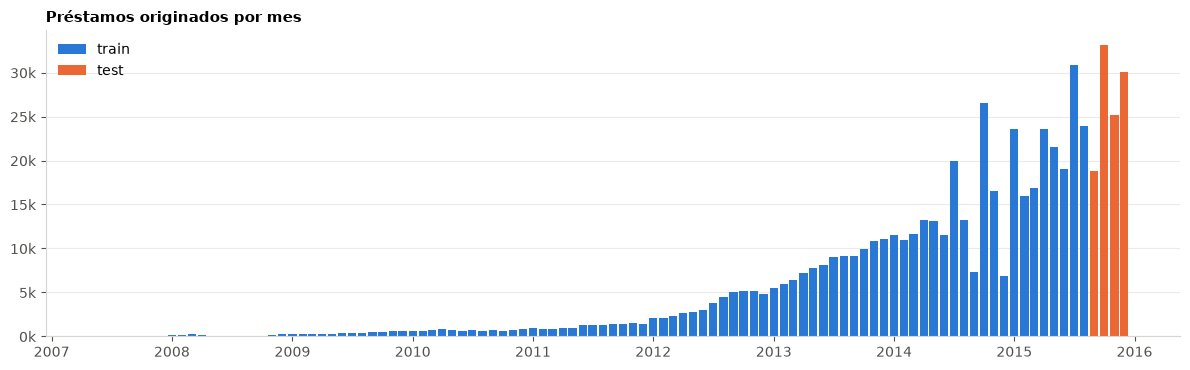

In [9]:
fig, ax = plt.subplots(figsize=(12, 3.8))
for conjunto, color in [(train, AZUL), (test, NARANJA)]:
    por_mes = conjunto.groupby('fecha_originacion').size()
    ax.bar(por_mes.index, por_mes.values, width=25, color=color,
           label='train' if conjunto is train else 'test')
ax.set_title('Préstamos originados por mes')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{v/1000:.0f}k'))
ax.legend(loc='upper left')
plt.tight_layout()
guardar(fig, '05_split_temporal')
plt.show()

**Lectura.**
- Train: junio de 2007 a agosto de 2015 (511.150 préstamos). Test: septiembre a diciembre de 2015 (107.195).
- El volumen de Lending Club crece fuertemente con los años: por eso el 20% más reciente de los préstamos cubre solo 4 meses.
- La tasa de default de test **no se mira en esta entrega**: se reserva para la evaluación de la Entrega 03.

A partir de acá **todo el análisis exploratorio y las decisiones de preprocesamiento se toman sobre `train`**. A `test` solo se le aplican las mismas transformaciones (Sección 8), sin analizarlo. Para ajustar hiperparámetros, la Entrega 03 usará validación temporal dentro de train, no el test.

## 5. Diagnóstico de calidad de los datos

Esta sección describe los datos de **train** sin mirar todavía la variable objetivo; la relación con el default se analiza en la Sección 6. Las correcciones que surgen de acá son reglas fila a fila (Sección 8.1), así que se aplican igual a test sin necesidad de analizarlo.

### 5.1 Tipos de datos y duplicados

In [10]:
originales = train[columnas_originales]
print('Tipos de datos (tal como se leen del CSV):')
print(originales.dtypes.astype(str).value_counts().to_string())
print()
print(f"IDs duplicados: {train['id'].duplicated().sum()}")
print(f"Filas duplicadas (ignorando id y url): {originales.drop(columns=['id', 'url']).duplicated().sum()}")

Tipos de datos (tal como se leen del CSV):
float64    114
object      36
int64        1

IDs duplicados: 0


Filas duplicadas (ignorando id y url): 0


No hay duplicados. Las 36 columnas de texto incluyen categóricas (`home_ownership`, `purpose`), fechas en formato `Mon-YYYY` (`issue_d`, `earliest_cr_line`) y texto libre. A diferencia de otras versiones del dataset, en esta `int_rate` y `revol_util` ya vienen como números (sin el símbolo `%`).

El tipo de pandas no alcanza para decidir cómo tratar cada variable. La siguiente tabla clasifica las 98 variables ex-ante (las candidatas a feature) según su **tipo conceptual**:

In [11]:
nominales = ['term', 'purpose', 'home_ownership', 'addr_state',
             'application_type', 'verification_status_joint']
texto_libre = ['emp_title', 'title', 'desc', 'zip_code']

def tipo_conceptual(col):
    serie = originales[col]
    if serie.isna().all():
        return 'Vacía en la población'
    if col == 'emp_length':
        return 'Categórica ordinal'
    if col in nominales:
        return 'Categórica nominal'
    if col in texto_libre:
        return 'Texto libre / alta cardinalidad'
    if col in ('earliest_cr_line', 'sec_app_earliest_cr_line'):
        return 'Fecha'
    valores = serie.dropna()
    if (valores % 1 == 0).all() and valores.nunique() <= 100:
        return 'Numérica discreta (conteos, puntajes)'
    return 'Numérica continua (montos, ratios, meses)'

tipos = pd.Series({c: tipo_conceptual(c) for c in F.EX_ANTE}, name='tipo')
tabla_tipos = tipos.groupby(tipos).agg(
    variables='size', ejemplos=lambda s: ', '.join(s.index[:5]))
tabla_tipos.sort_values('variables', ascending=False)

,variables,ejemplos
tipo,,
Vacía en la población,30,"annual_inc_joint, dti_joint, verification_stat..."
"Numérica continua (montos, ratios, meses)",29,"loan_amnt, annual_inc, dti, mths_since_last_de..."
"Numérica discreta (conteos, puntajes)",28,"fico_range_low, fico_range_high, delinq_2yrs, ..."
Categórica nominal,5,"term, purpose, home_ownership, addr_state, app..."
Texto libre / alta cardinalidad,4,"title, desc, emp_title, zip_code"
Fecha,1,earliest_cr_line
Categórica ordinal,1,emp_length


- **Numéricas continuas y discretas**: la mayoría (buró de crédito). Las continuas (montos, ratios) son las candidatas a transformar (logaritmo, winsorización); las discretas (conteos de cuentas o consultas, FICO) se usan como números.
- **Categóricas nominales**: sin orden entre categorías → one-hot (Sección 8).
- **`emp_length`**: la única ordinal (antigüedad laboral) → se convierte a número de años, no a dummies.
- **Fecha** (`earliest_cr_line`): no se usa directamente; se transforma en antigüedad crediticia.
- **Texto libre / alta cardinalidad**: `emp_title` tiene más de 200 mil valores distintos, `title` repite a `purpose`, `desc` dejó de pedirse en 2014 y `zip_code` tiene cientos de valores (3 dígitos) cuya información geográfica ya aporta `addr_state`. Se descartan.
- **Vacías**: las de solicitudes conjuntas y el buró reportado desde diciembre de 2015 (Sección 5.2).

### 5.2 Valores faltantes

Hay tres tipos de faltante, y cada uno requiere un tratamiento distinto:
1. **Columnas 100% vacías**: no aplican a esta población.
2. **Faltante estructural por período**: variables que Lending Club empezó a reportar a partir de cierta fecha.
3. **Faltante informativo**: el vacío significa que el evento nunca ocurrió (por ejemplo, "meses desde la última mora" vacío = nunca tuvo una mora).

In [12]:
faltantes = originales.isna().mean().sort_values(ascending=False)
vacias = faltantes[faltantes == 1].index.tolist()
print(f"Columnas con algún faltante: {(faltantes > 0).sum()} de {len(faltantes)}")
print(f"Columnas 100% vacías ({len(vacias)}): {vacias}")

Columnas con algún faltante: 102 de 151
Columnas 100% vacías (32): ['member_id', 'sec_app_num_rev_accts', 'sec_app_open_act_il', 'sec_app_inq_last_6mths', 'sec_app_open_acc', 'dti_joint', 'open_rv_24m', 'total_cu_tl', 'annual_inc_joint', 'verification_status_joint', 'mths_since_rcnt_il', 'open_il_24m', 'open_il_12m', 'open_act_il', 'open_acc_6m', 'il_util', 'total_bal_il', 'open_rv_12m', 'inq_last_12m', 'inq_fi', 'all_util', 'max_bal_bc', 'next_pymnt_d', 'sec_app_mths_since_last_major_derog', 'sec_app_mort_acc', 'sec_app_fico_range_high', 'sec_app_revol_util', 'revol_bal_joint', 'sec_app_fico_range_low', 'sec_app_chargeoff_within_12_mths', 'sec_app_collections_12_mths_ex_med', 'sec_app_earliest_cr_line']


Las columnas 100% vacías en train son `member_id` (Lending Club lo anonimizó), `next_pymnt_d` (los préstamos ya terminaron), las de solicitudes conjuntas y co-solicitante (la población es solo de solicitudes individuales) y las 14 del buró que Lending Club empezó a reportar en diciembre de 2015, ya dentro del período de test. Se descartan.

Para ver el faltante estructural, el siguiente gráfico muestra la cobertura (% de préstamos con dato) de una selección de variables por año de originación.

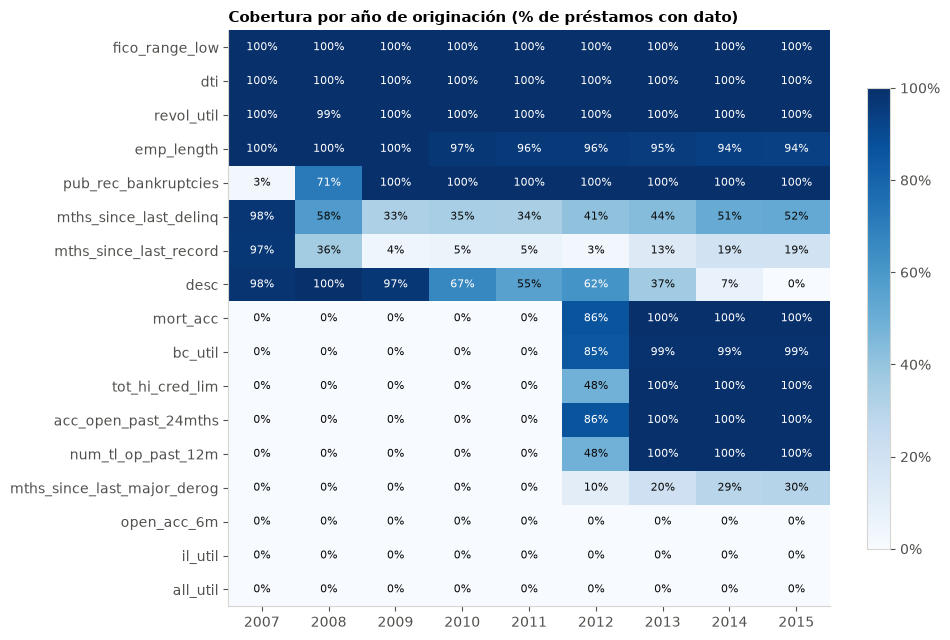

In [13]:
seleccion = [
    'fico_range_low', 'dti', 'revol_util', 'emp_length', 'pub_rec_bankruptcies',
    'mths_since_last_delinq', 'mths_since_last_record', 'desc',
    'mort_acc', 'bc_util', 'tot_hi_cred_lim', 'acc_open_past_24mths', 'num_tl_op_past_12m',
    'mths_since_last_major_derog', 'open_acc_6m', 'il_util', 'all_util',
]
cobertura = (originales[seleccion].notna()
             .groupby(train['fecha_originacion'].dt.year).mean().T)

fig, ax = plt.subplots(figsize=(10, 6.5))
im = ax.imshow(cobertura.values, cmap=CMAP_SECUENCIAL, vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(cobertura.shape[1]), cobertura.columns)
ax.set_yticks(range(cobertura.shape[0]), cobertura.index)
ax.grid(False)
for i in range(cobertura.shape[0]):
    for j in range(cobertura.shape[1]):
        v = cobertura.values[i, j]
        ax.text(j, i, f'{v:.0%}', ha='center', va='center', fontsize=8,
                color='white' if v > 0.6 else '#0b0b0b')
ax.set_title('Cobertura por año de originación (% de préstamos con dato)')
fig.colorbar(im, ax=ax, format=pct, shrink=0.8)
plt.tight_layout()
guardar(fig, '02_cobertura_por_anio')
plt.show()

In [14]:
# Grupos de variables según su patrón de faltante
buro_2015 = ['open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il',
             'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util',
             'inq_fi', 'total_cu_tl', 'inq_last_12m']
desde_2013 = train['fecha_originacion'] >= '2013-01-01'
print('Faltante del buró extendido, cosechas 2013 a ago-2015 (máximo por variable):',
      f"{originales.loc[desde_2013, F.BURO_EXTENDIDO].isna().mean().max():.1%}")
print('Faltante del buró extendido, cosechas 2007-2011:',
      f"{originales.loc[train['fecha_originacion'] < '2012-01-01', F.BURO_EXTENDIDO].isna().mean().min():.1%}")
print('Faltante del buró reportado desde dic-2015, en train:',
      f"{originales[buro_2015].isna().mean().min():.1%}")

Faltante del buró extendido, cosechas 2013 a ago-2015 (máximo por variable): 10.4%
Faltante del buró extendido, cosechas 2007-2011: 100.0%
Faltante del buró reportado desde dic-2015, en train: 100.0%


**Diagnóstico.**
- **Buró básico** (`fico_range_low`, `dti`, `revol_util`, …): cobertura completa en todo el período. La excepción es `pub_rec_bankruptcies`, que Lending Club empezó a reportar en 2008 (3% de cobertura en 2007, 71% en 2008). Afecta a menos de 1.000 préstamos y se imputa con la mediana de train (0 quiebras).
- El 98% de cobertura de `mths_since_last_delinq` en 2007 no es un dato real: es el cambio de codificación que se analiza en la Sección 5.3.
- **Buró extendido** (`mort_acc`, `bc_util`, `tot_hi_cred_lim`, … — 34 variables): vacío hasta mediados de 2012, completo desde 2013. La excepción es `mths_since_recent_inq` (10,4% vacío en 2013 a ago-2015): ahí el vacío significa que no hubo consultas recientes. El faltante no es aleatorio: depende solo del período, no del solicitante. **Decisión**: se conservan, porque en el período más reciente (el que se parece al test y a la aplicación real) están completas y tienen poder predictivo (Sección 8). Se agrega un flag `buro_extendido_disponible` para que el modelo distinga "no reportado" de un valor real, y la imputación se ajusta solo con train.
- **Buró reportado desde diciembre de 2015** (`open_acc_6m`, `il_util`, `all_util`, … — 14 variables): 100% vacío en train. **Decisión**: se descartan; el modelo no tiene de dónde aprenderlas.
- **`desc`** (descripción libre del solicitante): Lending Club dejó de pedirla en 2014. Se descarta.
- **`mths_since_last_major_derog`, `mths_since_recent_bc_dlq`, `mths_since_recent_revol_delinq`**: combinan los dos problemas (reportadas desde 2012 y vacías cuando no hubo evento), así que un vacío no se puede interpretar. Se descartan; la información de moras previas queda cubierta por `delinq_2yrs` y `mths_since_last_delinq`.
- **`mths_since_last_delinq`, `mths_since_last_record`**: faltante informativo (nunca tuvo el evento). Se transforman en flags "tuvo mora previa" / "tuvo registro público" en vez de imputarlas (Sección 8).
- **`emp_length`** (~6%): el faltante coincide casi siempre con `emp_title` vacío (siguiente celda); indica que el solicitante no declaró empleo. Se agrega un flag de faltante.

### 5.3 Inconsistencias

In [15]:
trimestre = train['fecha_originacion'].dt.to_period('Q')
codificacion = pd.DataFrame({
    'mths_since_last_delinq = 0': (train['mths_since_last_delinq'] == 0).groupby(trimestre).mean(),
    'mths_since_last_delinq vacío': train['mths_since_last_delinq'].isna().groupby(trimestre).mean(),
    'mths_since_last_record = 0': (train['mths_since_last_record'] == 0).groupby(trimestre).mean(),
}).loc[:'2009Q2']
display(codificacion.round(3))

codificacion_vieja = (train['fecha_originacion'] <= '2008-03-01') & (train['mths_since_last_delinq'] == 0)
print(f"Préstamos hasta mar-2008 con mths_since_last_delinq = 0: {codificacion_vieja.sum()}")
print(f"  de ellos, con alguna mora en los últimos 2 años (delinq_2yrs > 0): {(train.loc[codificacion_vieja, 'delinq_2yrs'] > 0).sum()}")

,mths_since_last_delinq = 0,mths_since_last_delinq vacío,mths_since_last_record = 0
fecha_originacion,,,
2007Q2,0.000,0.000,1.000
2007Q3,0.704,0.074,0.877
2007Q4,0.592,0.000,0.947
2008Q1,0.485,0.115,0.744
2008Q2,0.007,0.586,0.007
2008Q3,0.000,0.559,0.005
2008Q4,0.000,0.622,0.000
2009Q1,0.000,0.637,0.000
2009Q2,0.000,0.693,0.000


Préstamos hasta mar-2008 con mths_since_last_delinq = 0: 439
  de ellos, con alguna mora en los últimos 2 años (delinq_2yrs > 0): 0


**Cambio de codificación en 2008.** Entre el tercer trimestre de 2007 y el primero de 2008, entre el 49% y el 70% de los préstamos tienen "meses desde la última mora = 0", y entre el 74% y el 95% tienen "meses desde el último registro público = 0". Desde el segundo trimestre de 2008 esos ceros desaparecen y aparece el vacío. Un 0 literal significaría que el solicitante estaba en mora el mismo mes en que pidió el préstamo; además, ninguno de esos préstamos tiene moras en los últimos 2 años (`delinq_2yrs = 0`), lo que sería imposible con una mora ese mismo mes. Conclusión: **en ese período Lending Club registraba "nunca tuvo el evento" como 0 en lugar de vacío**. Si no se corrige, el modelo interpretaría un solicitante sin moras como uno con una mora reciente. **Decisión**: en préstamos originados hasta marzo de 2008, el 0 se trata como vacío (`src/features.py`).

In [16]:
print('emp_title vacío vs. emp_length vacío:')
print(pd.crosstab(train['emp_title'].isna(), train['emp_length'].isna(),
                  rownames=['emp_title vacío'], colnames=['emp_length vacío']))
print()
inicio_credito = pd.to_datetime(train['earliest_cr_line'], format='%b-%Y')
print(f"Primera línea de crédito posterior a la solicitud: {(inicio_credito > train['fecha_originacion']).sum()}")
print(f"Primera línea de crédito más antigua: {inicio_credito.min():%b-%Y}")
print('Diferencia fico_range_high - fico_range_low:',
      (train['fico_range_high'] - train['fico_range_low']).value_counts().to_dict())

emp_title vacío vs. emp_length vacío:
emp_length vacío   False  True 
emp_title vacío                
False             477159    256
True                5544  28191



Primera línea de crédito posterior a la solicitud: 0
Primera línea de crédito más antigua: Jan-1944
Diferencia fico_range_high - fico_range_low: {4.0: 511101, 5.0: 49}


- Cuando falta `emp_length`, en el 99% de los casos también falta `emp_title`: es una no-respuesta sobre el empleo, no un error de carga.
- `earliest_cr_line` viene con año de 4 dígitos, así que no aparece el problema de fechas de otras versiones del dataset (años de 2 dígitos como "Jan-65" leídos como 2065). Ninguna primera línea de crédito es posterior a la solicitud.
- El FICO viene como un rango de 4 puntos (5 en unos pocos casos): `fico_range_low` y `fico_range_high` son redundantes y se promedian en una sola variable.

### 5.4 Variables constantes

In [17]:
constantes = [c for c in columnas_originales if originales[c].nunique(dropna=True) <= 1
              and c not in vacias]
print(f"Columnas con un único valor en la población: {constantes}")

Columnas con un único valor en la población: ['term', 'pymnt_plan', 'out_prncp', 'out_prncp_inv', 'policy_code', 'application_type', 'hardship_flag', 'hardship_type', 'deferral_term', 'hardship_length', 'disbursement_method']


No aportan información en esta población y se descartan. `term` es constante por construcción (solo 36 meses) y `application_type`, por el filtro de solicitudes individuales; `policy_code` y `disbursement_method` tienen un único valor en todo el período. El resto son ex-post (préstamos ya terminados: saldo pendiente 0, sin planes de pago).

### 5.5 Estadísticas descriptivas y outliers

In [18]:
num_clave = ['loan_amnt', 'annual_inc', 'dti', 'fico_range_low', 'revol_bal', 'revol_util',
             'open_acc', 'total_acc', 'inq_last_6mths', 'delinq_2yrs', 'pub_rec']
descriptivas = train[num_clave].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T
descriptivas.round(1)

,count,mean,std,min,1%,25%,50%,75%,99%,max
loan_amnt,511150.0,12431.7,7691.2,500.0,1500.0,6800.0,10000.0,16000.0,35000.0,35000.0
annual_inc,511150.0,71728.5,60443.9,3000.0,17200.0,42500.0,60000.0,85800.0,250000.0,8900060.0
dti,511150.0,17.4,8.2,0.0,1.8,11.2,16.9,23.1,36.6,40.0
fico_range_low,511150.0,695.2,31.0,625.0,660.0,670.0,690.0,710.0,795.0,845.0
revol_bal,511150.0,15329.3,21228.2,0.0,266.0,5828.0,10634.0,18651.0,84712.0,2904836.0
revol_util,510851.0,54.3,23.8,0.0,1.9,36.8,55.0,72.6,98.1,892.3
open_acc,511150.0,11.2,5.1,0.0,3.0,8.0,10.0,14.0,27.0,84.0
total_acc,511150.0,24.5,11.7,2.0,5.0,16.0,23.0,31.0,59.0,162.0
inq_last_6mths,511150.0,0.7,1.0,0.0,0.0,0.0,0.0,1.0,4.0,8.0
delinq_2yrs,511150.0,0.3,0.9,0.0,0.0,0.0,0.0,0.0,4.0,29.0


In [19]:
controles = {
    'dti > 100': (train['dti'] > 100).sum(),
    'dti = 999': (train['dti'] == 999).sum(),
    'dti vacío': train['dti'].isna().sum(),
    'annual_inc = 0': (train['annual_inc'] == 0).sum(),
    'annual_inc > 1.000.000': (train['annual_inc'] > 1_000_000).sum(),
    'revol_util > 100': (train['revol_util'] > 100).sum(),
    'revol_bal > 1.000.000': (train['revol_bal'] > 1_000_000).sum(),
}
pd.Series(controles, name='prestamos').to_frame()

,prestamos
dti > 100,0
dti = 999,0
dti vacío,0
annual_inc = 0,0
annual_inc > 1.000.000,75
revol_util > 100,1664
revol_bal > 1.000.000,9


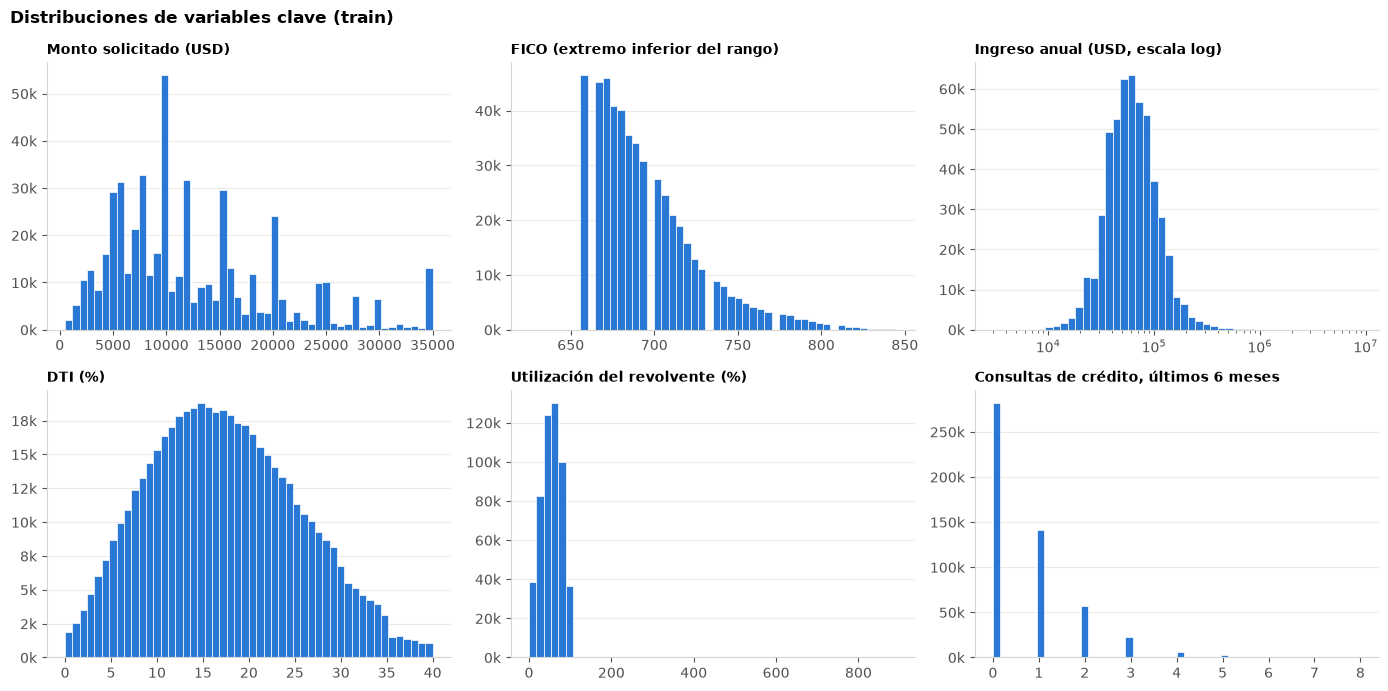

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
paneles = [
    ('loan_amnt', 'Monto solicitado (USD)', None),
    ('fico_range_low', 'FICO (extremo inferior del rango)', None),
    ('annual_inc', 'Ingreso anual (USD, escala log)', 'log'),
    ('dti', 'DTI (%)', None),
    ('revol_util', 'Utilización del revolvente (%)', None),
    ('inq_last_6mths', 'Consultas de crédito, últimos 6 meses', None),
]
for ax, (col, titulo, escala) in zip(axes.flat, paneles):
    datos_col = train[col].dropna()
    if escala == 'log':
        bins = np.logspace(np.log10(max(datos_col.min(), 1000)), np.log10(datos_col.max()), 50)
        ax.hist(datos_col.clip(lower=1000), bins=bins, color=AZUL, edgecolor='white', linewidth=0.5)
        ax.set_xscale('log')
    else:
        ax.hist(datos_col, bins=50, color=AZUL, edgecolor='white', linewidth=0.5)
    ax.set_title(titulo, fontsize=10)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{v/1000:.0f}k'))
plt.suptitle('Distribuciones de variables clave (train)', x=0.01, ha='left',
             fontweight='bold')
plt.tight_layout()
guardar(fig, '03_distribuciones')
plt.show()

**Outliers y valores fuera de rango.**
- **`dti`**: en esta población está entre 0 y 40, sin valores imposibles. Antes de excluir las solicitudes conjuntas aparecían 5 DTI mayores a 100 (uno de ellos 999, un valor centinela de Lending Club) y 2 ingresos de 0, todos en solicitudes conjuntas. `construir_features` igual los trata como faltantes (DTI > 100, ingreso ≤ 0), como protección si se aplica a otros datos.
- **`annual_inc`**: cola derecha muy larga (75 préstamos con más de USD 1M y un máximo de USD 8,9M). La cola no se elimina (puede ser real), pero se trabaja en logaritmo y se winsoriza al percentil 99,5 de train para los modelos lineales.
- **`revol_util > 100`** (~0,3%): utilizar más del 100% del límite es posible (sobregiro), así que no es un error; la winsorización acota los valores extremos (máx. 892%).
- **`revol_bal`** y los conteos (`open_acc`, `delinq_2yrs`, `pub_rec`) tienen colas largas pero plausibles: mismo tratamiento de winsorización.
- `loan_amnt` (USD 1.000-35.000) y FICO (625-845) no tienen valores imposibles. El piso de FICO en ~660 refleja la política de otorgamiento de Lending Club: los que tienen menos no reciben el préstamo (y por eso no están en el dataset).

La winsorización se ajusta **solo con train** (Sección 8), para no usar información del período de test.

### 5.6 Distribución de las variables categóricas

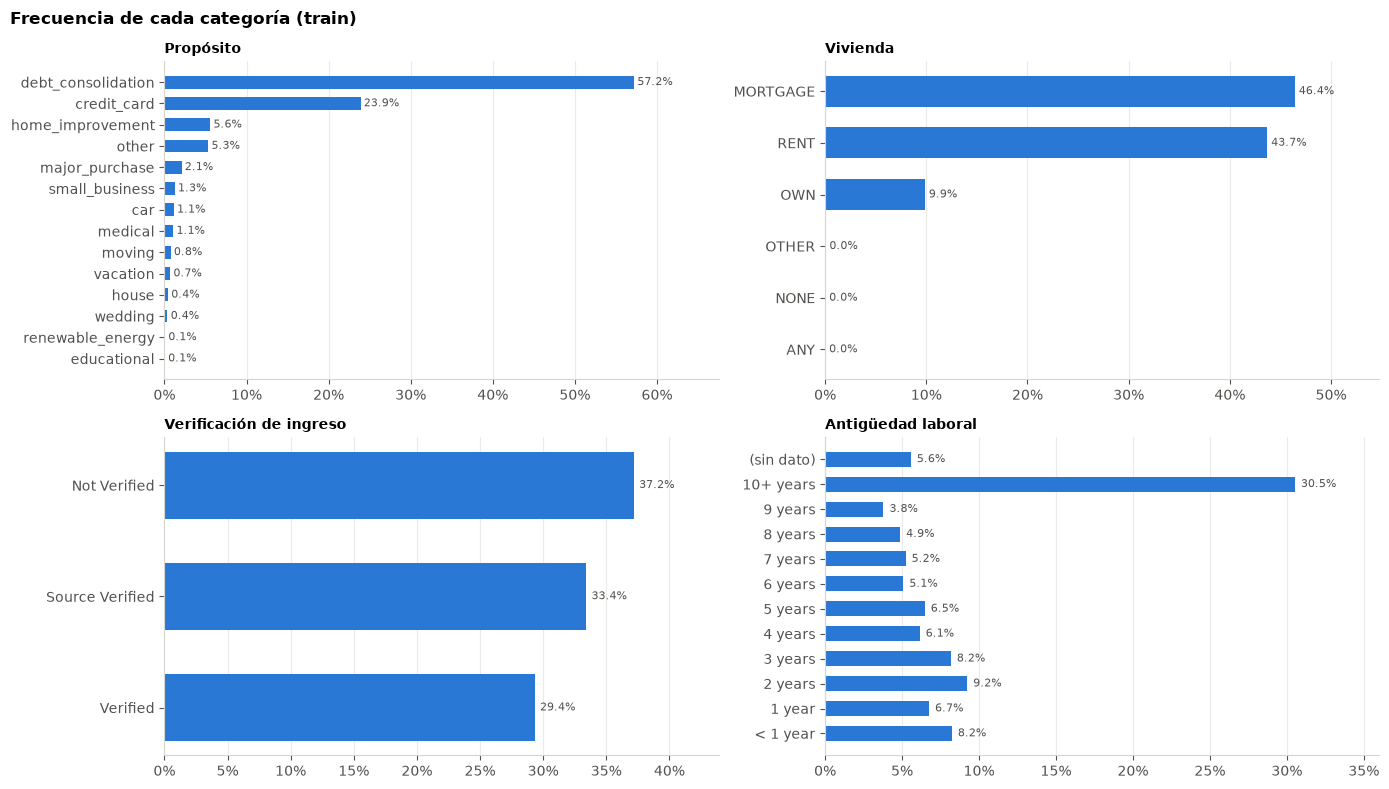

addr_state: 51 estados; los 5 más frecuentes: CA 15.8%, NY 8.6%, TX 8.0%, FL 7.0%, IL 4.0%
Estados con menos del 0,5% de los préstamos: 16


In [21]:
paneles = [('purpose', 'Propósito'), ('home_ownership', 'Vivienda'),
           ('verification_status', 'Verificación de ingreso'), ('emp_length', 'Antigüedad laboral')]
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (col, titulo) in zip(axes.flat, paneles):
    frecuencia = train[col].fillna('(sin dato)').value_counts(normalize=True)
    if col == 'emp_length':
        orden = ['< 1 year'] + [f'{i} year' + ('s' if i > 1 else '') for i in range(1, 10)] + ['10+ years', '(sin dato)']
        frecuencia = frecuencia.reindex(orden)
    else:
        frecuencia = frecuencia.sort_values()
    ax.barh(frecuencia.index, frecuencia.values, color=AZUL, height=0.6)
    for y, v in enumerate(frecuencia.values):
        ax.text(v + 0.004, y, f'{v:.1%}', va='center', fontsize=8, color='#52514e')
    ax.xaxis.set_major_formatter(pct)
    ax.set_xlim(0, frecuencia.max() * 1.18)
    ax.set_title(titulo, fontsize=10)
    ax.grid(axis='x')
    ax.grid(axis='y', visible=False)
plt.suptitle('Frecuencia de cada categoría (train)', x=0.01, ha='left', fontweight='bold')
plt.tight_layout()
guardar(fig, '04_frecuencias_categoricas')
plt.show()

estados = train['addr_state'].value_counts(normalize=True)
print(f"addr_state: {estados.size} estados; los 5 más frecuentes: "
      + ', '.join(f'{e} {v:.1%}' for e, v in estados.head(5).items()))
print(f"Estados con menos del 0,5% de los préstamos: {(estados < 0.005).sum()}")

**Lectura.**
- **Propósito**: muy concentrado. Consolidar deudas y pagar tarjetas de crédito suman más del 80% de los préstamos: en la práctica, Lending Club se usa para refinanciar deuda cara. Las categorías con menos del 0,5% (`educational`, `renewable_energy`, `wedding`, `house`) se agrupan en la codificación (Sección 8.3).
- **Vivienda**: casi todo se reparte entre hipoteca y alquiler; `OTHER`, `NONE` y `ANY` suman menos de 200 préstamos y se agrupan.
- **Verificación de ingreso**: las tres categorías tienen un peso parecido (29-37% cada una). Se describe por completitud, pero no se usa como feature (es una decisión de Lending Club, Sección 3).
- **Antigüedad laboral**: `10+ years` concentra casi un tercio porque es una categoría abierta (acumula todas las antigüedades de 10 años o más). El 6% sin dato es la no-respuesta sobre el empleo (Sección 5.3).
- **Estado de residencia**: 51 valores, con California a la cabeza; los estados con muy pocos préstamos también se agrupan en la codificación.

## 6. Análisis exploratorio sobre train

### 6.1 Balance de la variable objetivo

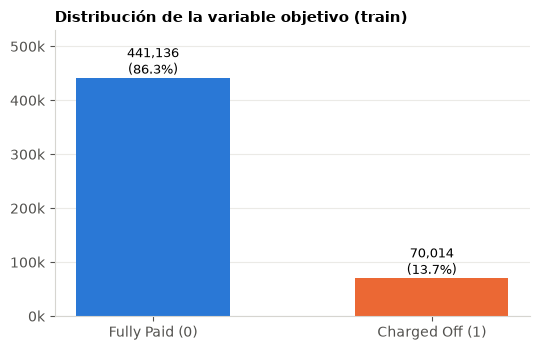

In [22]:
conteo = train['default'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(5.5, 3.6))
barras = ax.bar(['Fully Paid (0)', 'Charged Off (1)'], conteo.values, color=[AZUL, NARANJA], width=0.55)
for b, v in zip(barras, conteo.values):
    ax.text(b.get_x() + b.get_width() / 2, v, f'{v:,}\n({v / conteo.sum():.1%})',
            ha='center', va='bottom', fontsize=9)
ax.set_ylim(0, conteo.max() * 1.2)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{v/1000:.0f}k'))
ax.set_title('Distribución de la variable objetivo (train)')
plt.tight_layout()
guardar(fig, '06_target')
plt.show()

Uno de cada ~7 préstamos de train termina en default (13,7%). Es un desbalance moderado, no extremo, que se puede manejar en el modelado con pesos por clase (`class_weight`) y con métricas que no dependen del umbral (ROC-AUC, PR-AUC, KS), sin necesidad de *undersampling*. Accuracy no es una métrica útil: un modelo que prediga "nunca default" tendría 86% de accuracy.

### 6.2 Default por cosecha y ciclo económico

,prestamos,tasa_default
fecha_originacion,,
2007,251,17.9%
2008,"1,562",15.8%
2009,"4,716",12.6%
2010,"8,466",9.9%
2011,"14,101",10.6%
2012,"43,470",13.6%
2013,"100,422",12.3%
2014,"162,570",13.7%
2015,"175,592",14.9%


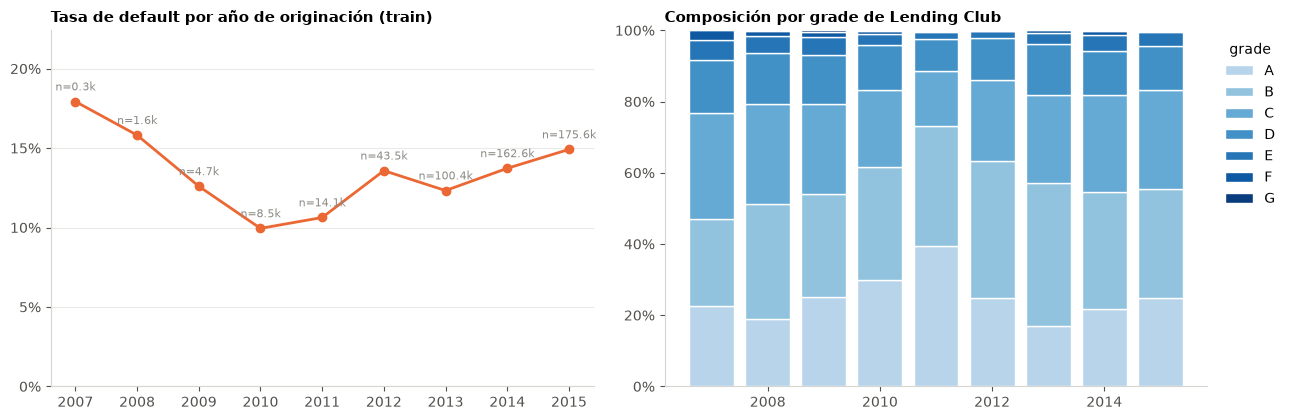

In [23]:
por_anio = train.groupby(train['fecha_originacion'].dt.year).agg(
    prestamos=('id', 'size'), tasa_default=('default', 'mean'))
mezcla_grade = pd.crosstab(train['fecha_originacion'].dt.year, train['grade'], normalize='index')
display(por_anio.style.format({'prestamos': '{:,}', 'tasa_default': '{:.1%}'}))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
axes[0].plot(por_anio.index, por_anio['tasa_default'], marker='o', color=NARANJA)
for anio, fila in por_anio.iterrows():
    axes[0].annotate(f"n={fila['prestamos']/1000:.1f}k", (anio, fila['tasa_default']),
                     textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8, color=GRIS)
axes[0].set_ylim(0, por_anio['tasa_default'].max() * 1.25)
axes[0].yaxis.set_major_locator(mtick.MultipleLocator(0.05))
axes[0].yaxis.set_major_formatter(pct)
axes[0].set_title('Tasa de default por año de originación (train)')

colores_grade = plt.get_cmap('Blues')(np.linspace(0.3, 0.95, mezcla_grade.shape[1]))
abajo = np.zeros(len(mezcla_grade))
for (grade, serie), color in zip(mezcla_grade.items(), colores_grade):
    axes[1].bar(mezcla_grade.index, serie, bottom=abajo, color=color, label=grade,
                edgecolor='white', linewidth=1)
    abajo += serie.values
axes[1].yaxis.set_major_formatter(pct)
axes[1].set_title('Composición por grade de Lending Club')
axes[1].legend(title='grade', bbox_to_anchor=(1.01, 1), loc='upper left')
axes[1].grid(False)
plt.tight_layout()
guardar(fig, '07_default_por_cosecha')
plt.show()

**Lectura.**
- **Crisis de 2008**: las cosechas 2007 (17,9%) y 2008 (15,8%) tienen las tasas de default más altas, aunque pesan poco en el total (~1.800 préstamos). La tasa baja fuerte en 2009-2011 (hasta 9,9% en 2010), cuando Lending Club endureció su política: la composición se desplaza hacia grades A y B (~73% de los préstamos de 2011).
- **2012-2015**: la tasa sube gradualmente, acompañando una mezcla con más peso de grades C a E: Lending Club fue otorgando a perfiles más riesgosos a medida que crecía.
- Parte de la variación de la tasa de default entre cosechas se explica por **quién** recibió préstamos (la mezcla de riesgo), no solo por el contexto macroeconómico. Con pocas cosechas de crisis no se pueden separar los dos efectos con precisión.
- **Implicancia para el modelo**: al mezclar cosechas de distintos momentos del ciclo sin variables macroeconómicas, la PD estimada va a ser un promedio *through-the-cycle*. Es una limitación que se documenta en la Sección 9. No se usa el año como feature: el modelo no puede extrapolar a años que no vio.

### 6.3 Variables numéricas vs. default

Para cada variable se agrupan los préstamos en deciles y se calcula la tasa de default de cada decil. Es una forma de ver la relación con el default sin suponer que es lineal.

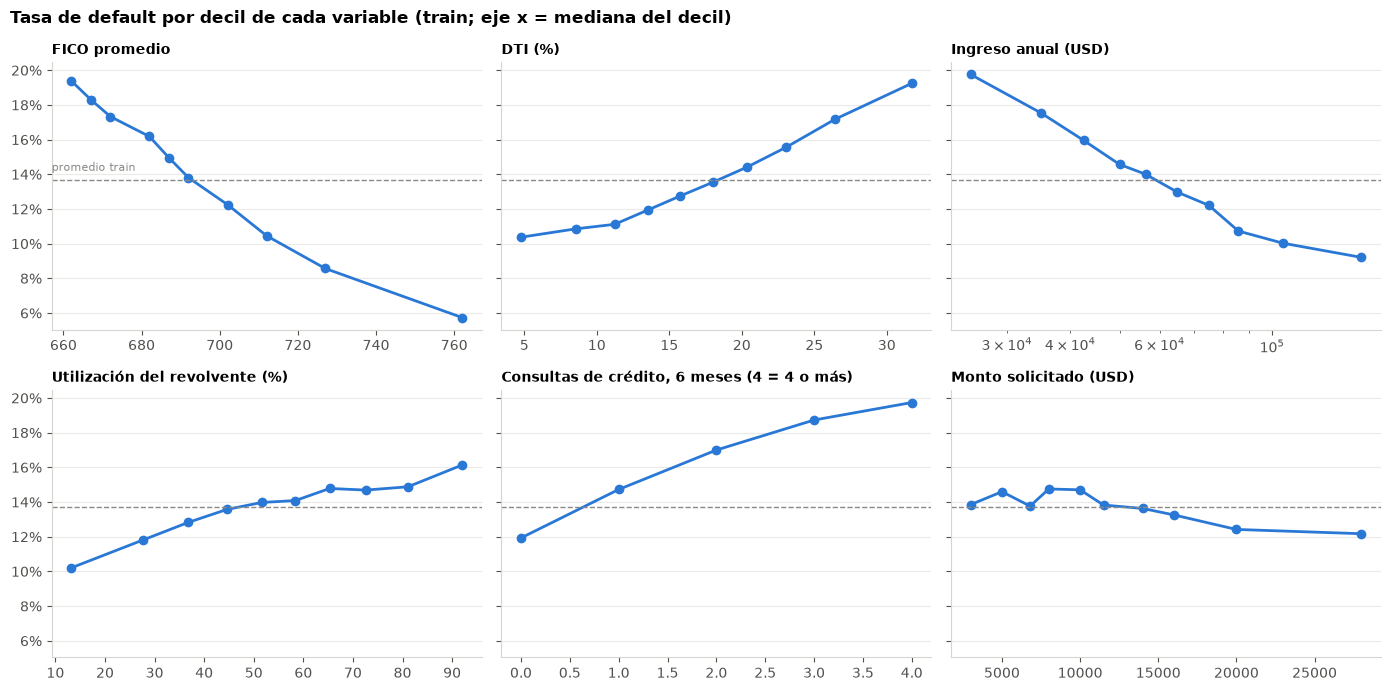

In [24]:
train['fico_promedio'] = (train['fico_range_low'] + train['fico_range_high']) / 2
paneles = [
    ('fico_promedio', 'FICO promedio'),
    ('dti', 'DTI (%)'),
    ('annual_inc', 'Ingreso anual (USD)'),
    ('revol_util', 'Utilización del revolvente (%)'),
    ('inq_last_6mths', 'Consultas de crédito, 6 meses (4 = 4 o más)'),
    ('loan_amnt', 'Monto solicitado (USD)'),
]
tasa_media = train['default'].mean()
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=True)
for ax, (col, titulo) in zip(axes.flat, paneles):
    datos_col = train[[col, 'default']].dropna()
    if col == 'inq_last_6mths':
        # Conteo con pocos valores: se agrupa por valor (4 o más juntos)
        grupos = datos_col[col].clip(upper=4)
    else:
        grupos = pd.qcut(datos_col[col].rank(method='first'), 10, labels=False)
    tabla = datos_col.groupby(grupos).agg(mediana=(col, 'median'), tasa=('default', 'mean'))
    ax.plot(tabla['mediana'], tabla['tasa'], marker='o', color=AZUL)
    ax.axhline(tasa_media, color=GRIS, linestyle='--', linewidth=1)
    ax.set_title(titulo, fontsize=10)
    ax.yaxis.set_major_formatter(pct)
    if col == 'annual_inc':
        ax.set_xscale('log')
axes[0, 0].text(axes[0, 0].get_xlim()[0], tasa_media + 0.005, 'promedio train', color=GRIS, fontsize=8)
plt.suptitle('Tasa de default por decil de cada variable (train; eje x = mediana del decil)',
             x=0.01, ha='left', fontweight='bold')
plt.tight_layout()
guardar(fig, '08_numericas_vs_default')
plt.show()

**Lectura.**
- **FICO** es la variable con la relación más fuerte: la tasa de default cae de forma monótona desde ~19% en el decil más bajo a ~6% en el más alto.
- **DTI**, **utilización del revolvente** y **consultas recientes** aumentan el riesgo de forma monótona: más endeudamiento y más búsqueda de crédito, más default.
- **Ingreso**: a mayor ingreso, menor default (de ~20% a ~9%), con una relación aproximadamente lineal en escala logarítmica (por eso se usa en logaritmo).
- **Monto solicitado**: relación débil y no monótona. Probablemente es más informativo en relación con el ingreso (`prestamo_sobre_ingreso`, Sección 8).

Las relaciones son las esperadas desde la teoría de riesgo crediticio, lo que respalda la calidad de las variables.

### 6.4 Variables categóricas vs. default

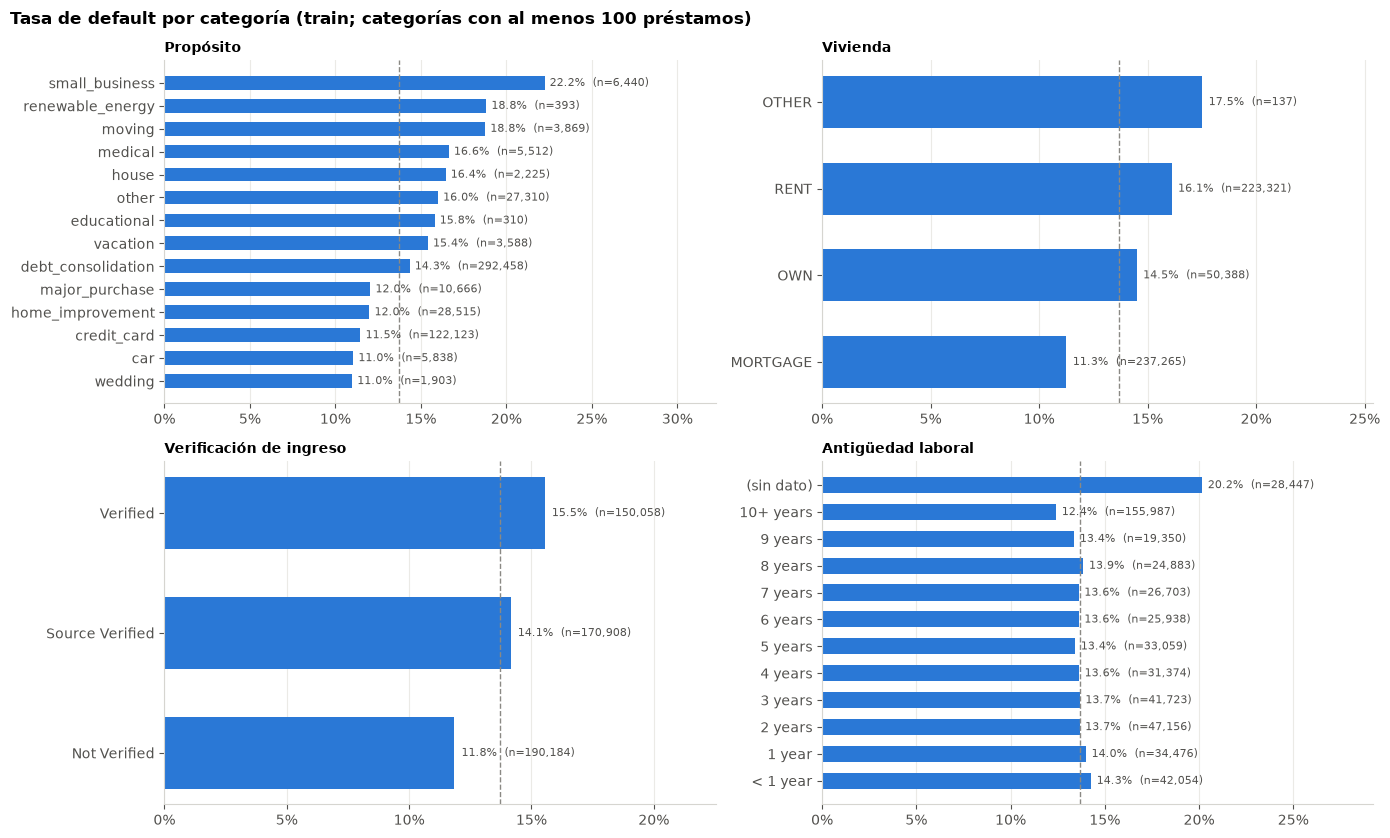

In [25]:
paneles = [('purpose', 'Propósito'), ('home_ownership', 'Vivienda'),
           ('verification_status', 'Verificación de ingreso'), ('emp_length', 'Antigüedad laboral')]
fig, axes = plt.subplots(2, 2, figsize=(14, 8.5))
for ax, (col, titulo) in zip(axes.flat, paneles):
    tabla = (train.assign(**{col: train[col].fillna('(sin dato)')})
             .groupby(col)['default'].agg(['mean', 'size']))
    if col == 'emp_length':
        orden = ['< 1 year'] + [f'{i} year' + ('s' if i > 1 else '') for i in range(1, 10)] + ['10+ years', '(sin dato)']
        tabla = tabla.reindex(orden)
    else:
        tabla = tabla[tabla['size'] >= 100].sort_values('mean')
    ax.barh(tabla.index, tabla['mean'], color=AZUL, height=0.6)
    for y, (tasa, n) in enumerate(zip(tabla['mean'], tabla['size'])):
        ax.text(tasa + 0.003, y, f'{tasa:.1%}  (n={n:,})', va='center', fontsize=8, color='#52514e')
    ax.axvline(tasa_media, color=GRIS, linestyle='--', linewidth=1)
    ax.xaxis.set_major_formatter(pct)
    ax.set_xlim(0, tabla['mean'].max() * 1.45)
    ax.set_title(titulo, fontsize=10)
    ax.grid(axis='x')
    ax.grid(axis='y', visible=False)
plt.suptitle('Tasa de default por categoría (train; categorías con al menos 100 préstamos)',
             x=0.01, ha='left', fontweight='bold')
plt.tight_layout()
guardar(fig, '09_categoricas_vs_default')
plt.show()

**Lectura.**
- **Propósito**: `small_business` es claramente el más riesgoso (22%); `credit_card`, `car` y `wedding` están entre los menos riesgosos (~11%). `debt_consolidation`, el más frecuente, está cerca del promedio.
- **Vivienda**: quienes alquilan (`RENT`, 16,1%) tienen más default que quienes tienen hipoteca (`MORTGAGE`, 11,3%).
- **Verificación de ingreso**: los préstamos **verificados tienen más default** (15,5%) que los no verificados (11,8%). No significa que verificar aumente el riesgo: Lending Club verifica con más frecuencia a los solicitantes que ya considera riesgosos. Es una variable que refleja la política de Lending Club y no una característica del solicitante: por eso **no se usa como feature** (Sección 3), con el mismo criterio que `grade`.
- **Antigüedad laboral**: poca diferencia entre años (12-14%). Lo que se destaca es el grupo **sin dato**, con 20% de default: confirma que el faltante es informativo y justifica el flag `emp_length_faltante`.

### 6.5 Benchmark: la calificación de Lending Club

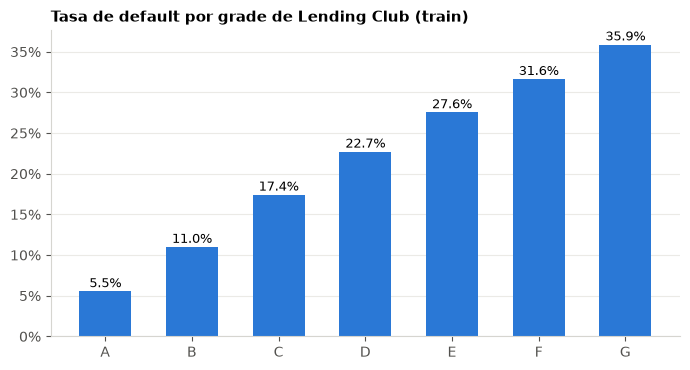

,AUC univariado
sub_grade (Lending Club),0.660
int_rate (Lending Club),0.653
fico_promedio (solicitante),0.601


In [26]:
por_grade = train.groupby('grade')['default'].agg(['mean', 'size'])

def auc_univariado(x, y):
    # AUC de una variable sola, en la dirección en que discrimina (>= 0,5)
    m = x.notna()
    auc = roc_auc_score(y[m], x[m])
    return max(auc, 1 - auc)

sub_grade_ordinal = train['sub_grade'].rank(method='dense')
benchmark = pd.Series({
    'sub_grade (Lending Club)': auc_univariado(sub_grade_ordinal, train['default']),
    'int_rate (Lending Club)': auc_univariado(train['int_rate'], train['default']),
    'fico_promedio (solicitante)': auc_univariado(train['fico_promedio'], train['default']),
}, name='AUC univariado').round(3)

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.bar(por_grade.index, por_grade['mean'], color=AZUL, width=0.6)
for x, (tasa, n) in enumerate(zip(por_grade['mean'], por_grade['size'])):
    ax.text(x, tasa + 0.005, f'{tasa:.1%}', ha='center', fontsize=9)
ax.yaxis.set_major_formatter(pct)
ax.set_title('Tasa de default por grade de Lending Club (train)')
plt.tight_layout()
guardar(fig, '10_default_por_grade')
plt.show()
benchmark.to_frame()

El `grade` de Lending Club separa bien el riesgo: la tasa de default crece de forma monótona de A a G. Con un AUC univariado de 0,66, el `sub_grade` es el **benchmark a superar en la Entrega 03**: nuestro modelo, con solo características del solicitante, debería discriminar al menos tan bien como la calificación de Lending Club. El FICO solo, sin ninguna otra variable, ya alcanza un AUC de 0,60.

### 6.6 Verificación empírica del leakage

Si la clasificación de la Sección 3 es correcta, las variables ex-post deberían "predecir" el default mucho mejor que cualquier variable ex-ante, porque en realidad lo describen después de ocurrido.

In [27]:
leakage = pd.Series({
    'last_fico_range_high (ex-post)': auc_univariado(train['last_fico_range_high'], train['default']),
    'capital cobrado / monto (ex-post)': auc_univariado(train['total_rec_prncp'] / train['funded_amnt'], train['default']),
    'debt_settlement_flag (ex-post)': auc_univariado((train['debt_settlement_flag'] == 'Y').astype(int), train['default']),
    'fico_promedio (ex-ante, la mejor)': auc_univariado(train['fico_promedio'], train['default']),
}, name='AUC univariado').round(3)
display(leakage.to_frame())

con_acuerdo = train['debt_settlement_flag'] == 'Y'
print(f"Préstamos con debt_settlement_flag = 'Y': {con_acuerdo.sum():,} ({con_acuerdo.mean():.1%} de train)")
print(f"  de ellos, en default: {train.loc[con_acuerdo, 'default'].mean():.1%}")
print(f"  defaults con acuerdo de pago: {con_acuerdo[train['default'] == 1].mean():.1%}")

,AUC univariado
last_fico_range_high (ex-post),0.909
capital cobrado / monto (ex-post),1.000
debt_settlement_flag (ex-post),0.549
"fico_promedio (ex-ante, la mejor)",0.601


Préstamos con debt_settlement_flag = 'Y': 6,833 (1.3% de train)
  de ellos, en default: 100.0%
  defaults con acuerdo de pago: 9.8%


El FICO actualizado (`last_fico_range_high`) alcanza sola un AUC de 0,91 y el capital cobrado separa en forma perfecta (AUC 1,00), contra 0,60 de la mejor variable ex-ante. `debt_settlement_flag` tiene un AUC bajo solo porque es poco frecuente (lo tiene el ~10% de los defaults), pero, como muestran los conteos de arriba, prácticamente todos los préstamos con "Y" son default. Un modelo que las incluyera tendría un desempeño espectacular en el test y sería inútil en producción: al momento de la solicitud esa información no existe. Esto confirma empíricamente que la exclusión es necesaria.

## 7. Cálculo empírico del LGD

El LGD (*Loss Given Default*) es la proporción de la exposición que se pierde cuando un préstamo entra en default. Se calcula sobre los préstamos de **train** en default, con las variables ex-post reservadas para esto:

- **EAD** (*Exposure at Default*) = monto financiado − capital cobrado antes del default. Es lo que el prestatario todavía debía al dejar de pagar.
- **Recupero neto** = `recoveries` (cobrado después del charge-off) − `collection_recovery_fee` (costo de cobranza).
- **LGD = 1 − recupero neto / EAD**, acotado a [0, 1].

La función vive en `src/features.py` (`calcular_perdida`). Además del LGD devuelve la EAD y la **pérdida sobre el monto** de cada préstamo en default, que se guardan también para test: son la pérdida observada contra la que la Entrega 04 valida la prima por banda (KPI de cobertura de pérdida esperada del Entregable 01).

In [28]:
columnas_perdida = ['ead', 'lgd', 'perdida_sobre_monto']
train[columnas_perdida] = F.calcular_perdida(train)
test[columnas_perdida] = F.calcular_perdida(test)

en_default = train[train['default'] == 1].copy()
en_default['recupero_neto'] = en_default['recoveries'] - en_default['collection_recovery_fee']
en_default['ead_sobre_monto'] = en_default['ead'] / en_default['funded_amnt']

print(f"Préstamos en default (train): {len(en_default):,}")
print(f"  EAD <= 0 (capital cobrado completo; LGD indefinido): {(en_default['ead'] <= 0).sum()}")
print(f"  Recupero neto mayor que la EAD (LGD acotado a 0): {(en_default['recupero_neto'] > en_default['ead']).sum()}")
print(f"  Sin ningún recupero: {(en_default['recoveries'] == 0).mean():.1%}")
print()
pd.DataFrame({
    'LGD (sobre EAD)': en_default['lgd'].describe(),
    'EAD / monto': en_default['ead_sobre_monto'].describe(),
    'Pérdida / monto': en_default['perdida_sobre_monto'].describe(),
}).round(3)

Préstamos en default (train): 70,014
  EAD <= 0 (capital cobrado completo; LGD indefinido): 0
  Recupero neto mayor que la EAD (LGD acotado a 0): 40
  Sin ningún recupero: 19.4%



,LGD (sobre EAD),EAD / monto,Pérdida / monto
count,70014.000,70014.000,70014.000
mean,0.891,0.578,0.517
std,0.126,0.241,0.230
min,0.000,0.000,0.000
25%,0.859,0.399,0.341
50%,0.914,0.605,0.537
75%,0.999,0.775,0.700
max,1.000,1.000,1.000


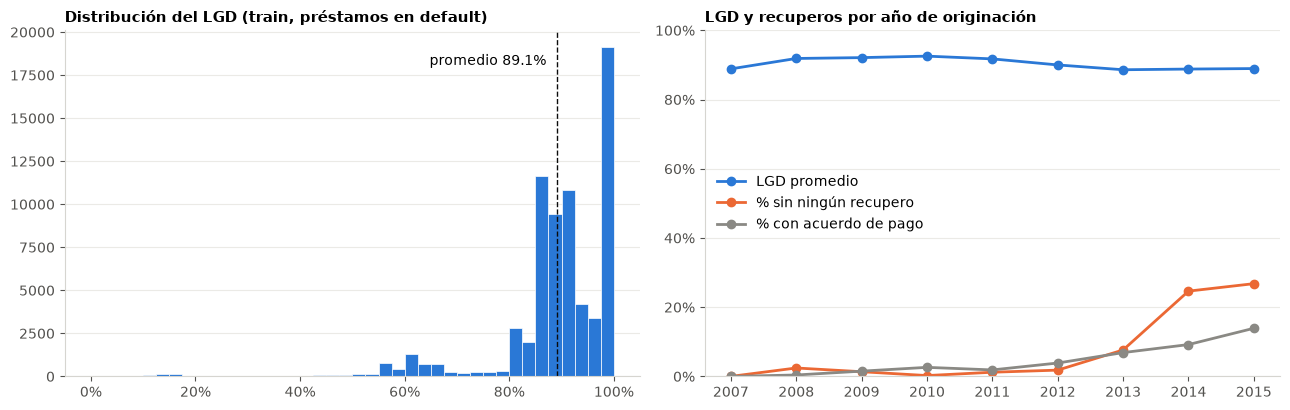

,defaults,lgd,sin_recupero,con_acuerdo_de_pago
fecha_originacion,,,,
2007,45,0.889,0.000,0.000
2008,247,0.919,0.024,0.004
2009,594,0.921,0.013,0.015
2010,842,0.925,0.002,0.026
2011,1499,0.917,0.012,0.019
2012,5903,0.900,0.018,0.039
2013,12378,0.886,0.076,0.069
2014,22315,0.888,0.246,0.092
2015,26191,0.890,0.268,0.139


In [29]:
por_cosecha = en_default.groupby(en_default['fecha_originacion'].dt.year).agg(
    defaults=('id', 'size'), lgd=('lgd', 'mean'),
    sin_recupero=('recoveries', lambda s: (s == 0).mean()),
    con_acuerdo_de_pago=('debt_settlement_flag', lambda s: (s == 'Y').mean()))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].hist(en_default['lgd'].dropna(), bins=40, color=AZUL, edgecolor='white', linewidth=0.5)
media_lgd = en_default['lgd'].mean()
axes[0].axvline(media_lgd, color='#0b0b0b', linestyle='--', linewidth=1)
axes[0].text(media_lgd - 0.02, axes[0].get_ylim()[1] * 0.9, f'promedio {media_lgd:.1%}', ha='right')
axes[0].xaxis.set_major_formatter(pct)
axes[0].set_title('Distribución del LGD (train, préstamos en default)')

axes[1].plot(por_cosecha.index, por_cosecha['lgd'], marker='o', color=AZUL, label='LGD promedio')
axes[1].plot(por_cosecha.index, por_cosecha['sin_recupero'], marker='o', color=NARANJA, label='% sin ningún recupero')
axes[1].plot(por_cosecha.index, por_cosecha['con_acuerdo_de_pago'], marker='o', color=GRIS, label='% con acuerdo de pago')
axes[1].yaxis.set_major_formatter(pct)
axes[1].set_ylim(0, 1)
axes[1].set_title('LGD y recuperos por año de originación')
axes[1].legend(loc='center left')
plt.tight_layout()
guardar(fig, '11_lgd')
plt.show()
por_cosecha.round(3)

**Lectura.**
- El **LGD promedio es ~89%** (mediana ~91%): una vez que un préstamo entra en default, se pierde casi todo lo que quedaba por cobrar. Es un valor alto pero esperable para préstamos personales **sin garantía**: no hay un bien que ejecutar y el recupero depende de la gestión de cobranza.
- La distribución **no es normal**: está concentrada cerca de 100%, con una cola hacia valores bajos (préstamos con acuerdos de pago o recuperos parciales). El promedio resume bien el caso típico pero oculta esa dispersión.
- En las cosechas 2014-2015 aumenta el porcentaje de préstamos **sin ningún recupero** (25-27%, contra 1-2% en 2008-2012). Puede deberse a que el proceso de recupero de los defaults más recientes todavía no había terminado a la fecha de corte, y a que más préstamos se cerraron con acuerdos de pago. Llama la atención que el LGD promedio por cosecha se mantenga estable (~88-92%): un préstamo sin recupero tiene LGD = 100%, así que el resto tiene que estar compensando. Se analiza en la Sección 7.1.
- **EAD / monto ≈ 58%**: en promedio, un préstamo que entra en default ya devolvió ~42% del capital. Por eso la **pérdida sobre el monto original** es ~52%, bastante menor que el LGD.

**Conexión con la prima de riesgo (Entregable 01).** La propuesta planteaba Prima ≈ PD × LGD. Para que la prima quede expresada como porcentaje del **monto prestado**, la fórmula completa es:

$$\text{Prima} = PD \times LGD \times \frac{EAD}{\text{monto}} \;=\; PD \times \text{pérdida sobre el monto}$$

Usar solo PD × LGD supondría que el prestatario no devolvió nada de capital antes del default (EAD = 100% del monto) y sobreestimaría la prima en ~70% (0,89 en lugar de 0,52 por unidad de PD). **Decisión para la Entrega 04**: usar el LGD promedio de train (~89%) junto con el EAD/monto promedio (~58%), es decir, una pérdida esperada dado default de ~52% del monto. El valor exacto sale de esta sección y queda guardado junto al dataset (columna `lgd`). Usar el promedio fijo, en lugar de modelar el LGD por solicitante, es una simplificación consciente.

**Unidad de la prima.** La PD de este modelo es la probabilidad de default **durante toda la vida** del préstamo (36 meses), así que la prima resultante es la pérdida esperada **acumulada** como % del monto, no un porcentaje anual. Para compararla con `int_rate` (una tasa anual) o sumarla a una tasa base, en la Entrega 04 hay que expresarla por año de exposición: dividirla por la vida promedio del saldo del préstamo, que en un préstamo amortizable a 36 meses es bastante menor que 3 años (el saldo baja con cada cuota y muchos préstamos se precancelan). Esa vida promedio se puede estimar con los datos de pago de train.

### 7.1 ¿Por qué el LGD promedio no sube si hay más préstamos sin recupero?

Un préstamo sin ningún recupero tiene LGD = 100% por construcción. Si en 2014-2015 una de cada cuatro pérdidas no tiene recupero (contra 1-2% antes), el LGD promedio solo puede mantenerse estable si el resto de los defaults pierde menos. Para ver de dónde sale la compensación, se separan los defaults de train en tres grupos:

- **Con acuerdo de pago** (`debt_settlement_flag = Y`): el prestatario negoció pagar una parte de la deuda.
- **Con recupero**: sin acuerdo, pero con algún monto cobrado después del charge-off.
- **Sin recupero ni acuerdo**: no se cobró nada después del charge-off (todavía).

El LGD promedio de cada cosecha es el promedio de los tres grupos ponderado por su peso:

In [30]:
grupo = np.select(
    [en_default['debt_settlement_flag'] == 'Y', en_default['recoveries'] > 0],
    ['con acuerdo de pago', 'con recupero'],
    default='sin recupero ni acuerdo')
anio = en_default['fecha_originacion'].dt.year.rename('cosecha')

descomposicion = pd.concat({
    '% de los defaults': pd.crosstab(anio, grupo, normalize='index'),
    'LGD promedio': en_default.pivot_table(index=anio, columns=grupo, values='lgd', aggfunc='mean'),
    'EAD / monto': en_default.pivot_table(index=anio, columns=grupo, values='ead_sobre_monto', aggfunc='mean'),
}, axis=1)
descomposicion.columns.names = ['', 'grupo']
descomposicion.round(3)

% de los defaults                                             LGD promedio                                              EAD / monto               \
grupo   con acuerdo de pago con recupero sin recupero ni acuerdo con acuerdo de pago con recupero sin recupero ni acuerdo con acuerdo de pago con recupero   
cosecha                                                                                                                                                      
2007                  0.000        1.000                   0.000                 NaN        0.889                     NaN                 NaN        0.562   
2008                  0.004        0.972                   0.024               1.000        0.916                     1.0               0.080        0.610   
2009                  0.015        0.971                   0.013               0.706        0.923                     1.0               0.537        0.634   
2010                  0.026        0.973                   0.001               0.689        0.932                     1.0               0.408        0.598   
2011                  0.019        0.971                   0.010               0.826        0.918                     1.0               0.424        0.597   
2012                  0.039        0.947                   0.015               0.799        0.903                     1.0               0.370        0.596   
2013                  0.069        0.858                   0.073               0.711        0.890                     1.0               0.473        0.581   
2014                  0.092        0.671                   0.237               0.686        0.876                     1.0               0.483        0.580   
2015                  0.139        0.602                   0.258               0.693        0.887                     1.0               0.472        0.623   

                                 
grupo   sin recupero ni acuerdo  
cosecha                          
2007                        NaN  
2008                      0.845  
2009                      0.821  
2010                      1.000  
2011                      0.559  
2012                      0.616  
2013                      0.633  
2014                      0.578  
2015                      0.540

**Lectura.** La compensación viene de los **acuerdos de pago**:

- Los préstamos **sin recupero ni acuerdo** pierden el 100%, como era de esperar, y pasan de 2% o menos de los defaults (2008-2012) a 24-26% (2014-2015).
- Los préstamos **con acuerdo de pago** pierden bastante menos: su LGD es de ~69-71% en 2013-2015, contra ~88-93% de los que tuvieron un recupero común. Además, su peso crece de 4% (2012) a 14% (2015).
- El LGD de los préstamos **con recupero** se mantiene estable en todo el período (~88-93%).

En 2015, por ejemplo: 14% × 0,69 + 60% × 0,89 + 26% × 1,00 ≈ 0,89. Los acuerdos de pago, que pierden menos, compensan casi exactamente a los préstamos sin recupero, y por eso el promedio queda estable. Es una coincidencia de composición, no una señal de que el proceso de recupero sea el mismo en todas las cosechas.

Los préstamos sin recupero de 2014-2015 tienen además una EAD / monto algo más baja que los que tuvieron recupero (~54-58% contra ~58-62%): en promedio cayeron en default un poco más tarde. Eso es consistente con que parte de ellos se haya dado de baja cerca de la fecha de corte, con la gestión de cobranza todavía en curso.

**Implicancia.** El LGD de ~89% es un promedio de grupos con comportamientos muy distintos. Para la Entrega 04 se mantiene el promedio de train, pero hay que tener presente que (1) el grupo *sin recupero* de las cosechas recientes puede incluir recuperos que todavía no habían ocurrido a la fecha de corte, lo que sobreestima el LGD, y (2) si la proporción de acuerdos de pago cambia, el LGD promedio también cambia.


## 8. Transformaciones y dataset final

### 8.1 Limpieza y variables derivadas

`F.construir_features` aplica transformaciones **fila a fila, sin parámetros aprendidos de los datos**, así que se aplica igual a train y a test sin riesgo de leakage:

| Transformación | Detalle | Motivo |
|---|---|---|
| `dti` > 100 y `annual_inc` ≤ 0 → vacío | No aparecen en esta población; protección ante el centinela 999 | Valores imposibles (Sección 5.5) |
| `mths_since_*` = 0 → vacío hasta mar-2008 | Cambio de codificación | Sección 5.3 |
| `fico_promedio` | Promedio de `fico_range_low` y `fico_range_high` | Las dos son redundantes |
| `log_annual_inc` | Logaritmo del ingreso | Distribución muy asimétrica; relación con el default en escala log |
| `antiguedad_crediticia_anios` | `issue_d` − `earliest_cr_line` | Historia crediticia al momento de la solicitud |
| `emp_length_anios` | `< 1 year` → 0 … `10+ years` → 10 | Variable ordinal: número, no dummies |
| `prestamo_sobre_ingreso` | `loan_amnt` / `annual_inc` | El monto importa en relación con la capacidad de pago |
| `revol_bal_sobre_ingreso` | `revol_bal` / `annual_inc` | Idem para la deuda revolvente |
| `tuvo_mora_previa` | `mths_since_last_delinq` informado o `delinq_2yrs` > 0 | Faltante informativo → flag |
| `tuvo_registro_publico` | `mths_since_last_record` informado o `pub_rec` > 0 | Faltante informativo → flag |
| `emp_length_faltante` | Flag | No declaró empleo: más riesgo (Sección 6.4) |
| `buro_extendido_disponible` | Flag | Distingue "no reportado" (antes de 2012) de un valor real |
| `home_ownership` | `OTHER`, `NONE`, `ANY` → `OTHER` | Categorías con < 0,03% de los préstamos |

No se usa `installment` para construir un ratio cuota/ingreso: la cuota depende de la tasa que asignó Lending Club (benchmark), así que traería de vuelta su scoring de forma indirecta.

In [31]:
X_train = F.construir_features(train)
X_test = F.construir_features(test)
nuevas = ['fico_promedio', 'log_annual_inc', 'antiguedad_crediticia_anios', 'emp_length_anios',
          'prestamo_sobre_ingreso', 'revol_bal_sobre_ingreso', 'tuvo_mora_previa',
          'tuvo_registro_publico', 'emp_length_faltante', 'buro_extendido_disponible']
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
X_train[nuevas].describe().T.round(2)

X_train: (511150, 62), X_test: (107195, 62)


,count,mean,std,min,25%,50%,75%,max
fico_promedio,511150.0,697.17,31.03,627.00,672.00,692.00,712.00,847.50
log_annual_inc,511150.0,11.02,0.54,8.01,10.66,11.00,11.36,16.00
antiguedad_crediticia_anios,511150.0,15.95,7.53,3.00,10.83,14.42,19.67,71.00
emp_length_anios,482703.0,5.84,3.66,0.00,2.00,6.00,10.00,10.00
prestamo_sobre_ingreso,511150.0,0.20,0.11,0.00,0.12,0.18,0.27,0.83
revol_bal_sobre_ingreso,511150.0,0.23,0.20,0.00,0.10,0.18,0.30,10.22
tuvo_mora_previa,511150.0,0.48,0.50,0.00,0.00,0.00,1.00,1.00
tuvo_registro_publico,511150.0,0.15,0.36,0.00,0.00,0.00,0.00,1.00
emp_length_faltante,511150.0,0.06,0.23,0.00,0.00,0.00,0.00,1.00
buro_extendido_disponible,511150.0,0.90,0.30,0.00,1.00,1.00,1.00,1.00


### 8.2 Selección de variables

Dos reglas objetivas, calculadas sobre train:
1. **Casi-constantes**: se descartan las variables en las que más del 99% de los valores informados son iguales. Aportan muy poca información y hacen inestables los coeficientes de un modelo lineal.
2. **Redundantes**: para cada par con |correlación de Spearman| > 0,9 se conserva una sola: la de mayor cobertura y, si la cobertura difiere en menos de 1 punto, la de mayor AUC univariado. Los pares se recorren de mayor a menor correlación; si una de las dos variables ya se descartó por otro par, el par queda resuelto (así no se descartan las dos variables de un trío correlacionado).

No se hace una selección más agresiva por poder predictivo: eso es parte del modelado (Entrega 03), donde la regularización y la importancia de variables de los modelos de árboles lo resuelven mejor que un filtro univariado.

In [32]:
candidatas = F.NUMERICAS_BASE + F.BURO_EXTENDIDO + F.BINARIAS

# Regla 1: casi-constantes
moda = pd.Series({c: X_train[c].value_counts(normalize=True).iloc[0] for c in candidatas})
casi_constantes = moda[moda > 0.99].index.tolist()
print('Casi-constantes (> 99% de los valores iguales):')
print(moda[moda > 0.99].round(4).to_string())
assert sorted(casi_constantes) == sorted(F.DESCARTE_CASI_CONSTANTES)

Casi-constantes (> 99% de los valores iguales):
acc_now_delinq              0.9958
chargeoff_within_12_mths    0.9925
delinq_amnt                 0.9970
num_tl_120dpd_2m            0.9992
num_tl_30dpd                0.9970


In [33]:
# Poder discriminante univariado de cada candidata
restantes = [c for c in candidatas if c not in casi_constantes]
auc = pd.Series({c: auc_univariado(X_train[c], train['default']) for c in restantes}).sort_values()
cobertura_train = X_train[restantes].notna().mean()

# Regla 2: redundantes
numericas_restantes = [c for c in restantes if c not in F.BINARIAS]
correlacion = X_train[numericas_restantes].corr(method='spearman')
pares = [(a, b, correlacion.loc[a, b])
         for i, a in enumerate(numericas_restantes) for b in numericas_restantes[i + 1:]
         if abs(correlacion.loc[a, b]) > 0.9]
# Se recorren de mayor a menor correlación; si una variable del par ya se
# descartó, el par queda resuelto
redundantes, detalle = [], []
for a, b, r in sorted(pares, key=lambda p: -abs(p[2])):
    if a in redundantes or b in redundantes:
        detalle.append((a, b, round(r, 3), '(ya resuelto)'))
        continue
    if abs(cobertura_train[a] - cobertura_train[b]) > 0.01:
        descartar = a if cobertura_train[a] < cobertura_train[b] else b
    else:
        descartar = a if auc[a] < auc[b] else b
    redundantes.append(descartar)
    detalle.append((a, b, round(r, 3), descartar))
display(pd.DataFrame(detalle, columns=['variable A', 'variable B', 'Spearman', 'se descarta']))
assert sorted(set(redundantes)) == sorted(F.DESCARTE_REDUNDANTES)

,variable A,variable B,Spearman,se descarta
0,open_acc,num_sats,0.998,num_sats
1,num_actv_rev_tl,num_rev_tl_bal_gt_0,0.991,num_rev_tl_bal_gt_0
2,tot_cur_bal,tot_hi_cred_lim,0.974,tot_cur_bal
3,tot_cur_bal,avg_cur_bal,0.934,(ya resuelto)


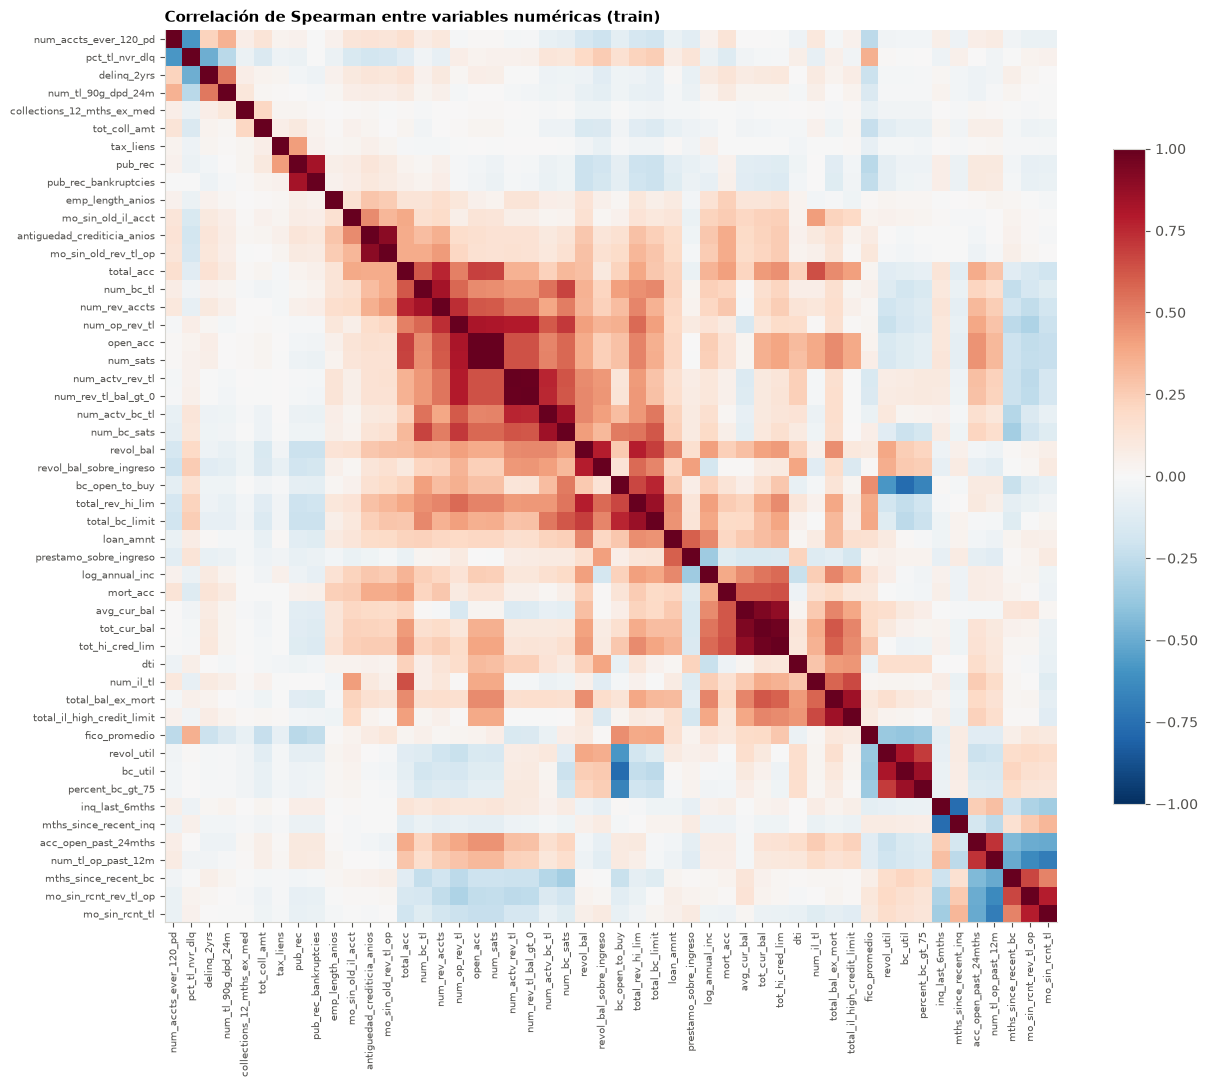

In [34]:
# Matriz de correlación de Spearman entre las numéricas (ordenada por grupos de variables parecidas)
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

distancia = 1 - correlacion.abs().fillna(0).to_numpy(copy=True)
np.fill_diagonal(distancia, 0)
orden = correlacion.index[leaves_list(linkage(squareform(distancia, checks=False), 'average'))]
matriz = correlacion.loc[orden, orden]

fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(matriz.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(orden)), orden, rotation=90, fontsize=7)
ax.set_yticks(range(len(orden)), orden, fontsize=7)
ax.grid(False)
ax.set_title('Correlación de Spearman entre variables numéricas (train)')
fig.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout()
guardar(fig, '13_correlacion_spearman')
plt.show()

**Lectura.** Las variables se ordenan de forma que las más correlacionadas quedan juntas, así se ven bloques de variables que miden casi lo mismo:

- **Cantidad de cuentas**: `open_acc`, `num_sats`, `num_op_rev_tl`, `num_actv_rev_tl`, `num_rev_tl_bal_gt_0`, `num_bc_sats`…
- **Límites y saldos**: `tot_hi_cred_lim`, `tot_cur_bal`, `avg_cur_bal`, y aparte `total_rev_hi_lim` / `total_bc_limit` / `revol_bal`.
- **Utilización de tarjetas**: `revol_util`, `bc_util`, `percent_bc_gt_75`, con correlación negativa con `bc_open_to_buy` (crédito disponible).
- **Antigüedad**: `antiguedad_crediticia_anios` y `mo_sin_old_rev_tl_op`.
- **Actividad reciente**: consultas y cuentas abiertas recientes (`inq_last_6mths`, `acc_open_past_24mths`, `num_tl_op_past_12m`), con correlación negativa con los "meses desde…" (`mths_since_recent_inq`, `mo_sin_rcnt_tl`): más actividad reciente, menos meses desde la última.

Es lo esperable en datos de buró. Los casos extremos (|ρ| > 0,9) son los pares descartados en la tabla de arriba. Las correlaciones moderadas se dejan: la regularización de la regresión logística y los modelos de árboles las manejan, y cada variable puede aportar un matiz distinto. El FICO tiene correlaciones bajas o moderadas con el resto (las más altas, con la utilización de tarjetas y el crédito disponible): aporta información que las demás variables no repiten.


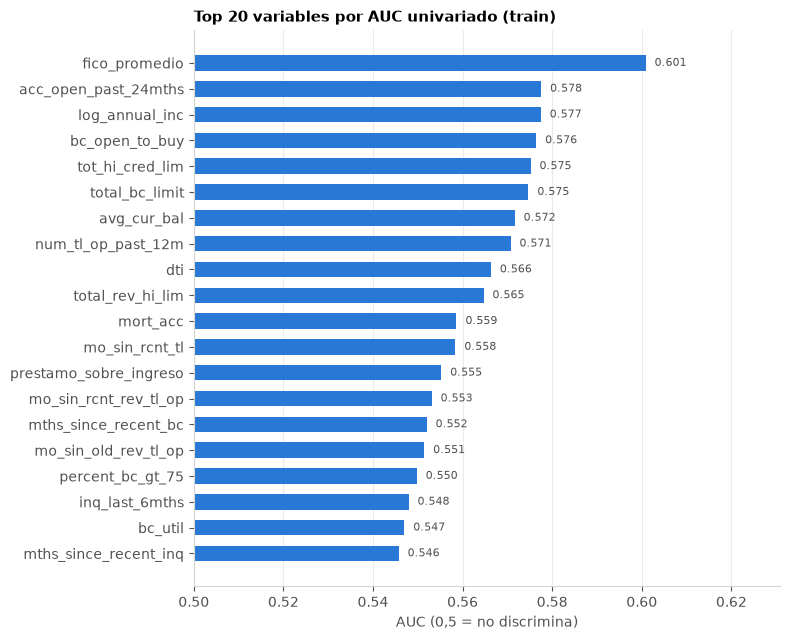

In [35]:
top = auc.drop(redundantes).tail(20)
fig, ax = plt.subplots(figsize=(8, 6.5))
ax.barh(top.index, top.values - 0.5, left=0.5, color=AZUL, height=0.6)
for y, v in enumerate(top.values):
    ax.text(v + 0.002, y, f'{v:.3f}', va='center', fontsize=8, color='#52514e')
ax.set_xlim(0.5, top.max() + 0.03)
ax.set_title('Top 20 variables por AUC univariado (train)')
ax.set_xlabel('AUC (0,5 = no discrimina)')
ax.grid(axis='x')
ax.grid(axis='y', visible=False)
plt.tight_layout()
guardar(fig, '12_auc_univariado')
plt.show()

- Los pares redundantes son esperables: `num_sats` (cuentas al día) y `open_acc` (cuentas abiertas) miden prácticamente lo mismo; `tot_cur_bal` (saldo total) está contenido en `avg_cur_bal` y `tot_hi_cred_lim`.
- El ranking confirma el EDA: el **FICO** lidera, seguido por variables de capacidad de pago (ingreso, DTI) y del buró extendido (límites de crédito, cuentas abiertas recientes, hipotecas). Individualmente todas discriminan poco (AUC < 0,61): el poder del modelo va a venir de combinarlas.
- Varias variables del buró extendido están entre las más discriminantes, lo que justifica haberlas conservado a pesar del faltante estructural.

In [36]:
numericas, binarias, categoricas = F.features_modelo()
print(f"Features finales: {len(numericas)} numéricas, {len(binarias)} binarias, {len(categoricas)} categóricas")
print(f"\nCategóricas: {categoricas}")
print(f"Binarias: {binarias}")

Features finales: 47 numéricas, 4 binarias, 3 categóricas

Categóricas: ['home_ownership', 'purpose', 'addr_state']
Binarias: ['tuvo_mora_previa', 'tuvo_registro_publico', 'emp_length_faltante', 'buro_extendido_disponible']


### 8.3 Codificación, imputación y estandarización

Las transformaciones que **aprenden de los datos** (percentiles, medianas, medias, desvíos, categorías) se ajustan **solo con train** y se aplican a test. `F.crear_preprocesador` las arma como un `ColumnTransformer` de scikit-learn:

| Paso | Variables | Detalle |
|---|---|---|
| Winsorización | Numéricas | Recorte a los percentiles 0,5% y 99,5% de train. Evita que los outliers dominen los coeficientes de un modelo lineal |
| Imputación | Numéricas | Mediana de train. Indicador de faltante solo para las 3 variables del buró extendido cuyo vacío es informativo (sin consultas recientes, sin cuentas en cuotas, sin tarjetas); el resto del faltante es estructural y lo captura `buro_extendido_disponible`. En esas 3 variables la mediana es solo un relleno: por ejemplo, un vacío en `mths_since_recent_inq` significa *sin consultas*, pero la mediana corresponde a una consulta reciente. La información la lleva el indicador, no el valor imputado |
| Estandarización | Numéricas | Media 0 y desvío 1 (`StandardScaler`). Necesaria para la regresión logística regularizada: sin ella la penalización trata distinto a variables en USD y en conteos |
| One-hot | `home_ownership`, `purpose`, `addr_state` | Sin orden natural entre categorías. Las categorías con < 0,5% de los préstamos se agrupan en `infrequent` (por ejemplo, estados chicos o `purpose = educational`); lo mismo con categorías nuevas que aparezcan en test |

**Estandarización y modelos de árboles**: Random Forest y Gradient Boosting son invariantes a transformaciones monótonas y manejan faltantes, así que para ellos (Entrega 03) solo hace falta la codificación de categóricas. El preprocesador completo es para el baseline de regresión logística.

In [37]:
preprocesador = F.crear_preprocesador(numericas, binarias, categoricas)
Z_train = preprocesador.fit_transform(X_train)
Z_test = preprocesador.transform(X_test)

print(f"Matriz de train: {Z_train.shape}  |  test: {Z_test.shape}")
print(f"Faltantes después del preprocesamiento: train {Z_train.isna().sum().sum()}, test {Z_test.isna().sum().sum()}")
print()
print('Control de estandarización (numéricas):')
print(pd.DataFrame({'media train': Z_train[numericas].mean(), 'desvío train': Z_train[numericas].std(),
                    'media test': Z_test[numericas].mean()}).describe().loc[['min', 'max']].round(3))

Matriz de train: (511150, 105)  |  test: (107195, 105)
Faltantes después del preprocesamiento: train 0, test 0

Control de estandarización (numéricas):


     media train  desvío train  media test
min         -0.0           1.0      -0.145
max          0.0           1.0       0.155


In [38]:
columnas_categoricas = [c for c in Z_train.columns if c.startswith(tuple(categoricas))]
print(f"Columnas one-hot: {len(columnas_categoricas)}")
print([c for c in columnas_categoricas if 'infrequent' in c or c.startswith('purpose')])
print(f"\nCategorías agrupadas como infrecuentes:")
for col, infrecuentes in zip(categoricas, preprocesador.named_transformers_['cat'].infrequent_categories_):
    print(f"  {col}: {list(infrecuentes) if infrecuentes is not None else '-'}")

Columnas one-hot: 51
['home_ownership_infrequent_sklearn', 'purpose_car', 'purpose_credit_card', 'purpose_debt_consolidation', 'purpose_home_improvement', 'purpose_major_purchase', 'purpose_medical', 'purpose_moving', 'purpose_other', 'purpose_small_business', 'purpose_vacation', 'purpose_infrequent_sklearn', 'addr_state_infrequent_sklearn']

Categorías agrupadas como infrecuentes:
  home_ownership: ['OTHER']
  purpose: ['educational', 'house', 'renewable_energy', 'wedding']
  addr_state: ['AK', 'DC', 'DE', 'IA', 'ID', 'ME', 'MS', 'MT', 'ND', 'NE', 'NH', 'RI', 'SD', 'VT', 'WV', 'WY']


- En train las numéricas quedan con media 0 y desvío 1 por construcción. En test la media se aleja de 0 porque se usan los parámetros de train: es lo correcto, y la diferencia refleja la evolución de la población (por ejemplo, la mayor cobertura del buró extendido en 2015).
- No quedan faltantes en ninguno de los dos conjuntos.

### 8.4 Dataset final

Se guardan train y test con:
- Las features limpias de `construir_features`, **antes** de imputar, winsorizar y estandarizar. Así la Entrega 03 ajusta el preprocesador dentro de cada fold de validación, sin filtrar información entre folds.
- `default` (variable objetivo), `id` y `fecha_originacion`.
- El benchmark de Lending Club (`grade`, `sub_grade`, `int_rate`), para comparar contra nuestras bandas (Entrega 03).
- La pérdida realizada de los préstamos en default (`funded_amnt`, `ead`, `lgd`, `perdida_sobre_monto`), para validar la prima por banda (Entrega 04).

Estas columnas **no son features**: el benchmark es el output del modelo de Lending Club y la pérdida es ex-post.

In [39]:
columnas_extra = ['id', 'fecha_originacion', 'default', 'grade', 'sub_grade', 'int_rate',
                  'funded_amnt', 'ead', 'lgd', 'perdida_sobre_monto']
features_finales = numericas + binarias + categoricas

for nombre, X, base in [('train', X_train, train), ('test', X_test, test)]:
    final = pd.concat([base[columnas_extra], X[features_finales]], axis=1)
    final.to_parquet(f'../data/{nombre}.parquet', index=False)
    print(f"data/{nombre}.parquet: {final.shape[0]:,} filas x {final.shape[1]} columnas")

data/train.parquet: 511,150 filas x 64 columnas


data/test.parquet: 107,195 filas x 64 columnas


## 9. Reflexión final

### Decisiones tomadas y justificación

| Decisión | Justificación |
|---|---|
| Dataset de Kaggle (2007-2018, 2,26M préstamos), el previsto en el Entregable 01 | Fuente completa y documentada; cubre un ciclo económico con cosechas de crisis |
| Target: `Charged Off` (1) vs. `Fully Paid` (0), excluyendo préstamos en curso | Solo préstamos con resultado observado |
| Solo **cosechas maduras** | Excluir los préstamos en curso sesga la tasa de default de las cosechas recientes (censura). Se verificó cosecha por cosecha (Sección 2.2) |
| Solo préstamos a **36 meses** (2007-2015) | PD con un horizonte homogéneo; los 60 meses maduros terminan en 2013 y no llegarían al test |
| Clasificación explícita de las 151 variables (ex-ante, ex-post, benchmark, originación) | Evitar leakage; se verificó empíricamente (Sección 6.6) |
| Split **temporal**, apenas definida la población y antes de todo el EDA; diagnóstico y EDA solo sobre train | El test representa el futuro; ninguna decisión mira el período de evaluación |
| `verification_status` fuera del modelo | Es una decisión de Lending Club correlacionada con su propio scoring; mismo criterio que `grade` |
| Buró extendido conservado con flag de disponibilidad | Faltante estructural por período; completo en los años más recientes y con poder predictivo |
| Corrección de la codificación del 0 en 2007-2008 | Inconsistencia de registro que invertiría el significado de la variable |
| Transformaciones con parámetros aprendidos ajustadas solo con train, en un pipeline reutilizable | Evitar leakage del test y garantizar la misma transformación en la Entrega 03 |
| LGD calculado sobre la EAD, no sobre el monto original; prima = PD × LGD × EAD/monto | Definición estándar; evita sobreestimar la prima en ~70%. Refina la fórmula PD × LGD del Entregable 01 |

### Dificultades encontradas

- **Volumen**: el archivo completo (2,26M × 151) no entra cómodo en memoria en una notebook estándar. Se resolvió leyendo por bloques, filtrando las cosechas maduras y guardando un parquet intermedio (`src/datos.py`).
- **Censura por maduración**: no es evidente a simple vista. Se detectó comparando el porcentaje de préstamos resueltos por cosecha y plazo, y condicionó el diseño de toda la población de modelado.
- **Faltantes de tres tipos** (columnas vacías, estructurales por período, informativos), que requieren tratamientos distintos. Imputar todo con la media habría mezclado "no reportado" con "no ocurrió".
- **Inconsistencias de registro** que solo aparecen cruzando variables con el tiempo, como el cambio de codificación de 2008.
- **Límites difusos entre ex-ante y ex-post**: variables como `grade`, `funded_amnt`, `initial_list_status` o `verification_status` existen al otorgar, pero no describen al solicitante. Hubo que definir un criterio (solo información del solicitante) y aplicarlo de forma consistente.

### Limitaciones

- El modelo queda acotado a préstamos a **36 meses**.
- La PD será **through-the-cycle**: no se incluyen variables macroeconómicas y hay pocas cosechas de crisis (~1.800 préstamos en 2007-2008).
- **Sesgo de selección**: el dataset solo tiene préstamos **otorgados**. El modelo aprende el riesgo de solicitantes que ya pasaron el filtro de Lending Club (por ejemplo, casi nadie con FICO < 660), y su desempeño sobre la población total de solicitantes no se puede medir con estos datos.
- El LGD de las cosechas 2014-2015 puede estar sobreestimado si sus procesos de recupero seguían abiertos a la fecha de corte, y el promedio mezcla grupos con pérdidas muy distintas (Sección 7.1).
- El **test cubre solo 4 meses** (sep-dic 2015), un período sin crisis: el desempeño medido ahí puede no representar otros momentos del ciclo.
- **KPI "mejora frente al criterio actual" (Entregable 01)**: la propuesta planteaba medir el default que se hubiera evitado *o el negocio que se hubiera capturado* frente a las decisiones de Lending Club. Con estos datos solo se puede medir la primera parte: entre los préstamos que Lending Club otorgó, cuántos defaults se evitarían y cuántos buenos pagadores se rechazarían al aplicar nuestras bandas. El negocio que se hubiera capturado aprobando solicitantes que Lending Club rechazó no se puede medir: el archivo de rechazados no tiene resultado de pago (nunca recibieron el préstamo). En la Entrega 03 el KPI se mide en esa versión acotada.

### Próximos pasos (Entrega 03)

- Entrenar Logistic Regression (baseline, con el preprocesador de la Sección 8.3), Random Forest y Gradient Boosting (LightGBM/XGBoost) sobre `data/train.parquet`, con validación temporal para los hiperparámetros.
- Evaluar sobre `data/test.parquet` con ROC-AUC, PR-AUC y KS, no con accuracy.
- Comparar contra el benchmark de Lending Club: `sub_grade` tiene un AUC univariado de 0,66 en train; la comparación justa es contra su AUC **en test**, calculado sobre los mismos préstamos que el modelo.
- Validar la robustez temporal con un backtest por año dentro de train (por ejemplo, entrenar hasta 2013 y evaluar en 2014) y comparar entrenar con todo train vs. solo desde 2012, cuando el buró extendido está completo.
- Medir el aporte de `addr_state` (modelo con y sin ella) y eliminarla si es marginal.
- Construir bandas de riesgo a partir de la PD y verificar que la tasa de default observada crezca de forma monótona entre bandas (KPI del Entregable 01).

### Próximos pasos (Entrega 04)

- Expresar la prima por año de exposición antes de compararla con `int_rate` (Sección 7) y validarla por banda contra la pérdida realizada de test.
